In [1]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.utils import AnalysisException

spark = (
    SparkSession.builder
    .appName("stn_0003")
    .master("local[*]")
    .config("spark.sql.session.timeZone", "America/Toronto")
    # .config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.10.0") \
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/04 01:22:42 WARN Utils: Your hostname, users-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.39 instead (on interface en0)
26/04/04 01:22:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/04 01:22:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/04 01:22:45 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
rides_path = "../../data/silver/rides"

try:
    rides_df = spark.read.parquet(rides_path)
except AnalysisException as e:
    raise RuntimeError(f"Could not read parquet dataset at {rides_path}: {e}")

schema_types = dict(rides_df.dtypes)

def as_timestamp(col_name: str):
    # Support either TIMESTAMP columns or epoch-milliseconds columns.
    if schema_types.get(col_name) == "timestamp":
        return F.col(col_name)
    return F.to_timestamp(F.from_unixtime((F.col(col_name).cast("double") / F.lit(1000.0))))

n_rows = rides_df.count()
n_cols = len(rides_df.columns)

summary_row = (
    rides_df
    .select(
        F.min(as_timestamp("start_time_ms")).alias("min_start_ts"),
        F.max(as_timestamp("start_time_ms")).alias("max_start_ts"),
        F.min(as_timestamp("end_time_ms")).alias("min_end_ts"),
        F.max(as_timestamp("end_time_ms")).alias("max_end_ts"),
        F.countDistinct("start_canonical_station_id").alias("n_start_stations"),
        F.countDistinct("end_canonical_station_id").alias("n_end_stations")
    )
    .collect()[0]
)

print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
print("Column names:", rides_df.columns)
print("Quick summary:", summary_row)

print("\nSample rows (start/end time + canonical station IDs):")
rides_df.select(
    "start_time_ms",
    "end_time_ms",
    "start_canonical_station_id",
    "end_canonical_station_id"
).show(8, truncate=False)

Rows: 39,377,433
Columns: 19
Column names: ['end_station_key', 'start_station_key', 'start_station_name', 'start_station_district', 'start_station_latitude', 'start_station_longitude', 'end_station_name', 'end_station_district', 'end_station_latitude', 'end_station_longitude', 'start_time_ms', 'end_time_ms', 'start_station_name_norm', 'end_station_name_norm', 'start_coord_key', 'end_coord_key', 'start_canonical_station_id', 'end_canonical_station_id', 'ride_year']
Quick summary: Row(min_start_ts=datetime.datetime(2023, 4, 12, 23, 42, 44), max_start_ts=datetime.datetime(2026, 2, 1, 12, 58, 38), min_end_ts=datetime.datetime(2023, 4, 12, 23, 45, 57), max_end_ts=datetime.datetime(2026, 2, 7, 22, 28, 20), n_start_stations=1433, n_end_stations=1438)

Sample rows (start/end time + canonical station IDs):
+-------------------+-------------------+--------------------------+------------------------+
|start_time_ms      |end_time_ms        |start_canonical_station_id|end_canonical_station_id|
+--

Trips touching station STN_0003: 460,154
   trip_year  start_count  end_count  total_count
0       2023        70579      66836       137415
1       2024        84104      71076       155180
2       2025        96162      74950       171112
3       2026         1469       1116         2585


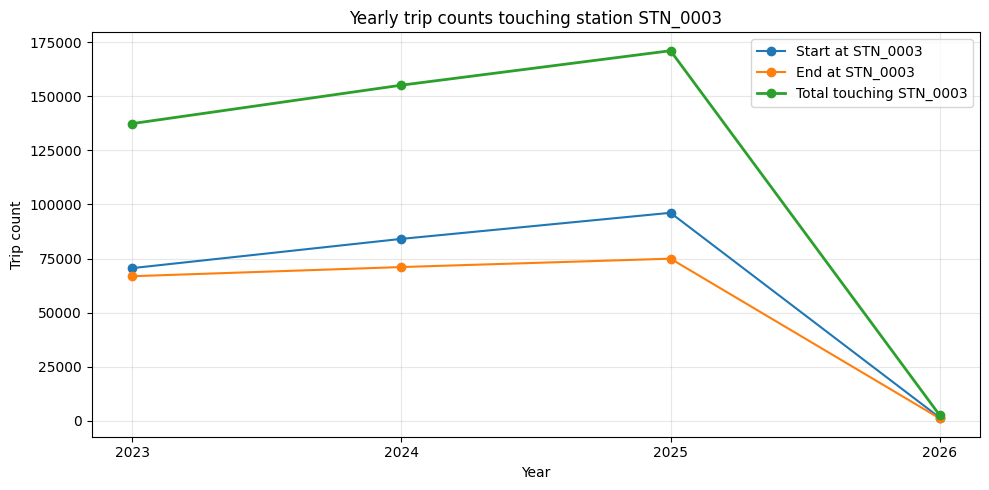

In [3]:
import matplotlib.pyplot as plt

TARGET_STATION = "STN_0003"

station_df = (
    rides_df
    .withColumn("trip_year", F.coalesce(F.col("ride_year"), F.year(F.col("start_time_ms"))))
    .filter(
        (F.col("start_canonical_station_id") == TARGET_STATION)
        | (F.col("end_canonical_station_id") == TARGET_STATION)
    )
    .cache()
)

print(f"Trips touching station {TARGET_STATION}:", f"{station_df.count():,}")

role_counts = (
    station_df
    .select(
        "trip_year",
        F.when(F.col("start_canonical_station_id") == TARGET_STATION, F.lit(1)).otherwise(F.lit(0)).alias("start_hit"),
        F.when(F.col("end_canonical_station_id") == TARGET_STATION, F.lit(1)).otherwise(F.lit(0)).alias("end_hit")
    )
    .groupBy("trip_year")
    .agg(
        F.sum("start_hit").alias("start_count"),
        F.sum("end_hit").alias("end_count")
    )
    .withColumn("total_count", F.col("start_count") + F.col("end_count"))
    .orderBy("trip_year")
)

role_counts_pd = role_counts.toPandas()
print(role_counts_pd)

# Treat year as categorical to show each year as a discrete value on x-axis.
year_labels = role_counts_pd["trip_year"].astype(int).astype(str)

plt.figure(figsize=(10, 5))
plt.plot(year_labels, role_counts_pd["start_count"], marker="o", label=f"Start at {TARGET_STATION}")
plt.plot(year_labels, role_counts_pd["end_count"], marker="o", label=f"End at {TARGET_STATION}")
plt.plot(year_labels, role_counts_pd["total_count"], marker="o", linewidth=2, label=f"Total touching {TARGET_STATION}")
plt.title(f"Yearly trip counts touching station {TARGET_STATION}")
plt.xlabel("Year")
plt.ylabel("Trip count")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
try:
    rides_df = spark.read.parquet(rides_path)
except AnalysisException as e:
    raise RuntimeError(f"Could not read parquet dataset at {rides_path}: {e}")

schema_types = dict(rides_df.dtypes)

def as_timestamp(col_name: str):
    """Convert either a timestamp column or epoch-milliseconds column to Spark timestamp."""
    dtype = schema_types.get(col_name)
    if dtype == "timestamp":
        return F.col(col_name)
    return F.to_timestamp(F.from_unixtime(F.col(col_name).cast("double") / F.lit(1000.0)))

rides_base_df = (
    rides_df
    .withColumn("start_ts", as_timestamp("start_time_ms"))
    .withColumn("end_ts", as_timestamp("end_time_ms"))
    .withColumn("trip_year", F.coalesce(F.col("ride_year"), F.year(F.col("start_ts"))))
)

n_rows = rides_base_df.count()
n_cols = len(rides_base_df.columns)

summary_row = (
    rides_base_df
    .select(
        F.min("start_ts").alias("min_start_ts"),
        F.max("start_ts").alias("max_start_ts"),
        F.min("end_ts").alias("min_end_ts"),
        F.max("end_ts").alias("max_end_ts"),
        F.countDistinct("start_canonical_station_id").alias("n_start_stations"),
        F.countDistinct("end_canonical_station_id").alias("n_end_stations")
    )
    .collect()[0]
)

print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
print("Quick summary:", summary_row)

rides_base_df.select(
    "start_ts",
    "end_ts",
    "trip_year",
    "start_canonical_station_id",
    "end_canonical_station_id"
).show(8, truncate=False)


Rows: 39,377,433
Columns: 22
Quick summary: Row(min_start_ts=datetime.datetime(2023, 4, 12, 23, 42, 44), max_start_ts=datetime.datetime(2026, 2, 1, 12, 58, 38), min_end_ts=datetime.datetime(2023, 4, 12, 23, 45, 57), max_end_ts=datetime.datetime(2026, 2, 7, 22, 28, 20), n_start_stations=1433, n_end_stations=1438)
+-------------------+-------------------+---------+--------------------------+------------------------+
|start_ts           |end_ts             |trip_year|start_canonical_station_id|end_canonical_station_id|
+-------------------+-------------------+---------+--------------------------+------------------------+
|2024-10-20 03:46:39|2024-10-20 03:59:50|2024     |STN_0069                  |STN_0324                |
|2024-05-09 19:23:41|2024-05-09 19:42:15|2024     |STN_0125                  |STN_0147                |
|2024-10-20 00:24:33|2024-10-20 00:32:18|2024     |STN_0112                  |STN_0059                |
|2024-05-09 17:11:11|2024-05-09 17:22:10|2024     |STN_0317   

Trips touching station STN_0003: 460,154


,trip_year,start_count,end_count,total_count
0,2023,70579,66836,137415
1,2024,84104,71076,155180
2,2025,96162,74950,171112
3,2026,1469,1116,2585


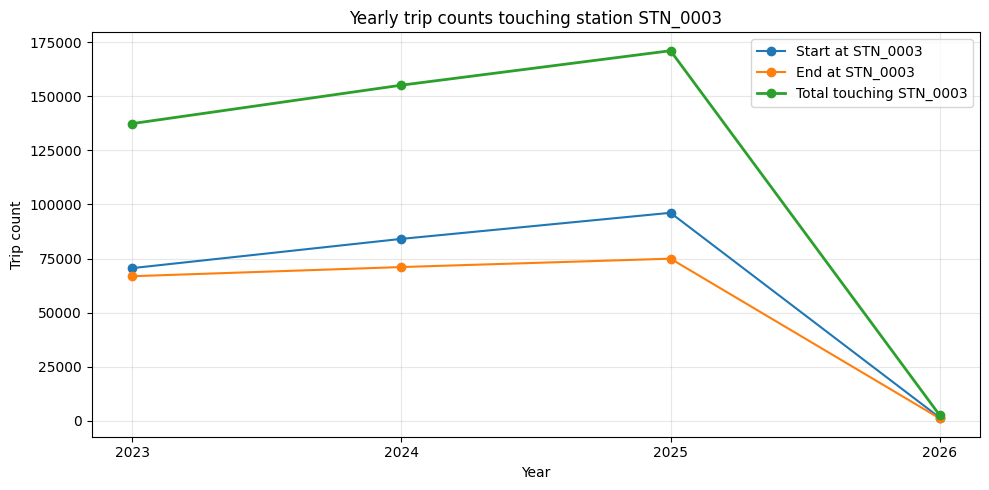

In [9]:
station_df = (
    rides_base_df
    .filter(
        (F.col("start_canonical_station_id") == TARGET_STATION) |
        (F.col("end_canonical_station_id") == TARGET_STATION)
    )
    .cache()
)

print(f"Trips touching station {TARGET_STATION}: {station_df.count():,}")

role_counts = (
    station_df
    .select(
        "trip_year",
        F.when(F.col("start_canonical_station_id") == TARGET_STATION, 1).otherwise(0).alias("start_hit"),
        F.when(F.col("end_canonical_station_id") == TARGET_STATION, 1).otherwise(0).alias("end_hit")
    )
    .groupBy("trip_year")
    .agg(
        F.sum("start_hit").alias("start_count"),
        F.sum("end_hit").alias("end_count")
    )
    .withColumn("total_count", F.col("start_count") + F.col("end_count"))
    .orderBy("trip_year")
)

role_counts_pd = role_counts.toPandas()
display(role_counts_pd)

if not role_counts_pd.empty:
    year_labels = role_counts_pd["trip_year"].astype("Int64").astype(str)

    plt.figure(figsize=(10, 5))
    plt.plot(year_labels, role_counts_pd["start_count"], marker="o", label=f"Start at {TARGET_STATION}")
    plt.plot(year_labels, role_counts_pd["end_count"], marker="o", label=f"End at {TARGET_STATION}")
    plt.plot(year_labels, role_counts_pd["total_count"], marker="o", linewidth=2, label=f"Total touching {TARGET_STATION}")
    plt.title(f"Yearly trip counts touching station {TARGET_STATION}")
    plt.xlabel("Year")
    plt.ylabel("Trip count")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No records found for the target station.")


Top connection points for STN_0003 by year (first 10 per year):

Year 2023


,station,out_count,in_count,total,year
0,STN_0003,2423,2423,4846,2023
1,STN_0022,1744,2339,4083,2023
2,STN_0096,1482,1808,3290,2023
3,STN_0058,1308,1208,2516,2023
4,STN_0010,1106,1019,2125,2023
5,STN_0033,874,1075,1949,2023
6,STN_0015,844,1090,1934,2023
7,STN_0123,903,936,1839,2023
8,STN_0001,713,1100,1813,2023
9,STN_0024,697,983,1680,2023



Year 2024


,station,out_count,in_count,total,year
778,STN_0005,2187,2066,4253,2024
779,STN_0028,2105,1599,3704,2024
780,STN_0056,1879,1577,3456,2024
781,STN_0003,1714,1714,3428,2024
782,STN_0018,1555,1297,2852,2024
783,STN_0103,1607,1110,2717,2024
784,STN_0177,1363,1158,2521,2024
785,STN_0096,1413,1090,2503,2024
786,STN_0220,1397,1031,2428,2024
787,STN_0057,1309,968,2277,2024



Year 2025


,station,out_count,in_count,total,year
1636,STN_0005,2857,2419,5276,2025
1637,STN_0028,2350,1645,3995,2025
1638,STN_0003,1965,1965,3930,2025
1639,STN_0056,1903,1485,3388,2025
1640,STN_0103,2121,1151,3272,2025
1641,STN_0018,1810,1366,3176,2025
1642,STN_0096,1757,1231,2988,2025
1643,STN_0220,1549,1041,2590,2025
1644,STN_0057,1380,850,2230,2025
1645,STN_0177,1112,934,2046,2025


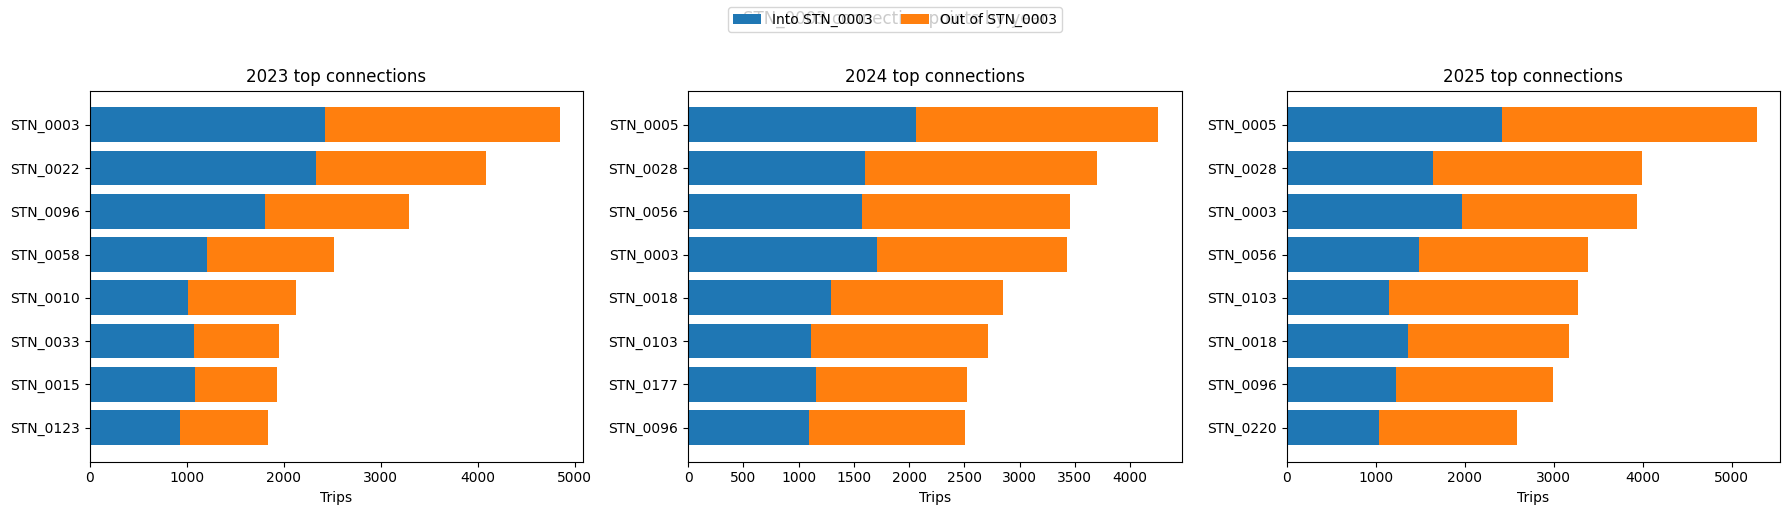

In [10]:
def build_year_connections(year: int):
    year_edges = (
        station_df
        .filter(F.col("trip_year") == year)
        .select(
            F.col("start_canonical_station_id").alias("src"),
            F.col("end_canonical_station_id").alias("dst")
        )
        .filter(F.col("src").isNotNull() & F.col("dst").isNotNull())
        .groupBy("src", "dst")
        .agg(F.count("*").alias("trip_count"))
    )

    out_conn = (
        year_edges
        .filter(F.col("src") == TARGET_STATION)
        .groupBy(F.col("dst").alias("station"))
        .agg(F.sum("trip_count").alias("out_count"))
    )

    in_conn = (
        year_edges
        .filter(F.col("dst") == TARGET_STATION)
        .groupBy(F.col("src").alias("station"))
        .agg(F.sum("trip_count").alias("in_count"))
    )

    return (
        out_conn
        .join(in_conn, on="station", how="full")
        .na.fill(0, subset=["out_count", "in_count"])
        .withColumn("total", F.col("out_count") + F.col("in_count"))
        .withColumn("year", F.lit(year))
    )

connection_frames = [build_year_connections(y) for y in YEARS]

if connection_frames:
    connections_all = connection_frames[0]
    for part in connection_frames[1:]:
        connections_all = connections_all.unionByName(part)

    connections_pd = connections_all.orderBy("year", F.desc("total")).toPandas()
else:
    connections_pd = pd.DataFrame(columns=["station", "out_count", "in_count", "total", "year"])

print(f"Top connection points for {TARGET_STATION} by year (first 10 per year):")
for y in YEARS:
    print(f"\nYear {y}")
    display(connections_pd[connections_pd["year"] == y].head(10))

if len(YEARS) > 0:
    fig, axes = plt.subplots(1, len(YEARS), figsize=(6 * len(YEARS), 5), sharex=False)
    if len(YEARS) == 1:
        axes = [axes]

    for ax, y in zip(axes, YEARS):
        top = connections_pd[connections_pd["year"] == y].nlargest(8, "total")
        if top.empty: 
            ax.text(0.5, 0.5, f"No connections\nfor {y}", ha="center", va="center")
            ax.set_title(str(y))
            ax.axis("off")
            continue

        labels = top["station"].astype(str)
        ax.barh(labels, top["in_count"], label=f"Into {TARGET_STATION}")
        ax.barh(labels, top["out_count"], left=top["in_count"], label=f"Out of {TARGET_STATION}")
        ax.invert_yaxis()
        ax.set_title(f"{y} top connections")
        ax.set_xlabel("Trips")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2)

    fig.suptitle(f"{TARGET_STATION} connection points by year", y=1.02)
    plt.tight_layout()
    plt.show()


In [12]:
YEARS = [2023, 2024, 2025]
ANALYSIS_YEARS = [2023, 2024]

2023-2024 inflow/outflow totals


,trip_year,direction,trip_count
0,2023,inflow,66814
1,2023,outflow,70239
2,2024,inflow,71075
3,2024,outflow,83672



Annual totals table


direction,inflow,outflow,total
trip_year,,,
2023,66814,70239,137053
2024,71075,83672,154747


inflow growth 2023->2024: 6.4%
outflow growth 2023->2024: 19.1%
total growth 2023->2024: 12.9%


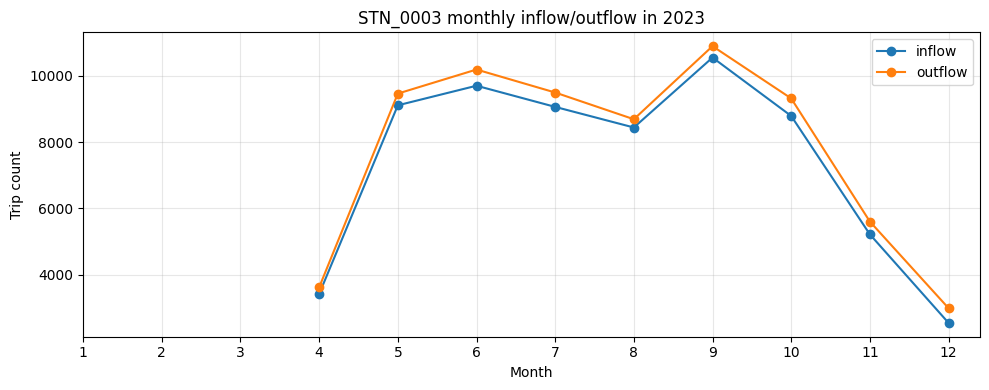

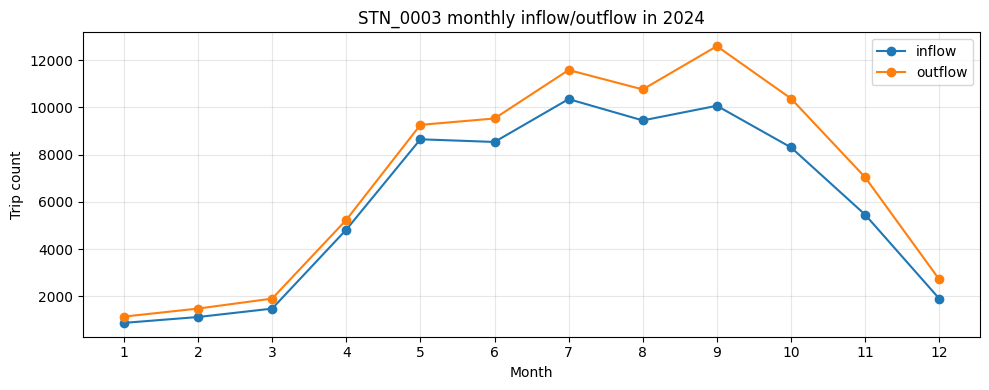

In [13]:
base_2023_2024 = rides_base_df.filter(F.col("trip_year").isin(ANALYSIS_YEARS))

outflow_df = (
    base_2023_2024
    .filter(F.col("start_canonical_station_id") == TARGET_STATION)
    .select(
        "trip_year",
        F.col("start_ts").alias("event_ts"),
        F.lit("outflow").alias("direction"),
        F.col("end_canonical_station_id").alias("counterpart_station")
    )
)

inflow_df = (
    base_2023_2024
    .filter(F.col("end_canonical_station_id") == TARGET_STATION)
    .select(
        "trip_year",
        F.col("end_ts").alias("event_ts"),
        F.lit("inflow").alias("direction"),
        F.col("start_canonical_station_id").alias("counterpart_station")
    )
)

flow_df = (
    outflow_df
    .unionByName(inflow_df)
    .filter(F.col("counterpart_station").isNotNull())
    .filter(F.col("event_ts").isNotNull())
    .withColumn("month", F.month("event_ts"))
    .withColumn("day_of_week", F.date_format("event_ts", "E"))
    .withColumn("hour", F.hour("event_ts"))
    .cache()
)

annual_direction = (
    flow_df
    .groupBy("trip_year", "direction")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("trip_year", "direction")
)

annual_direction_pd = annual_direction.toPandas()
print("2023-2024 inflow/outflow totals")
display(annual_direction_pd)

pivot_annual = (
    annual_direction_pd
    .pivot(index="trip_year", columns="direction", values="trip_count")
    .fillna(0)
    .astype(int)
)

if not pivot_annual.empty:
    pivot_annual["total"] = pivot_annual.sum(axis=1)
    print("\nAnnual totals table")
    display(pivot_annual)

    if len(pivot_annual.index) >= 2:
        years_sorted = sorted(pivot_annual.index.tolist())
        y0, y1 = years_sorted[0], years_sorted[1]
        for c in ["inflow", "outflow", "total"]:
            if c in pivot_annual.columns and pivot_annual.loc[y0, c] > 0:
                growth = (pivot_annual.loc[y1, c] / pivot_annual.loc[y0, c]) - 1
                print(f"{c} growth {y0}->{y1}: {growth:.1%}")
else:
    print("No inflow/outflow records found for the selected years.")

monthly_direction = (
    flow_df
    .groupBy("trip_year", "month", "direction")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("trip_year", "month", "direction")
)

monthly_pd = monthly_direction.toPandas()

if not monthly_pd.empty:
    for year in sorted(monthly_pd["trip_year"].dropna().unique()):
        subset = monthly_pd[monthly_pd["trip_year"] == year]
        pivot_month = subset.pivot(index="month", columns="direction", values="trip_count").fillna(0)

        plt.figure(figsize=(10, 4))
        for col in pivot_month.columns:
            plt.plot(pivot_month.index, pivot_month[col], marker="o", label=col)
        plt.title(f"{TARGET_STATION} monthly inflow/outflow in {year}")
        plt.xlabel("Month")
        plt.ylabel("Trip count")
        plt.xticks(range(1, 13))
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


Top counterpart stations by year and direction:
    trip_year direction counterpart_station  trip_count  rank  total_in_group  \
0        2023    inflow            STN_0003        2423     1           66814   
1        2023    inflow            STN_0022        2339     2           66814   
2        2023    inflow            STN_0096        1808     3           66814   
3        2023    inflow            STN_0058        1208     4           66814   
4        2023    inflow            STN_0001        1100     5           66814   
5        2023    inflow            STN_0015        1090     6           66814   
6        2023    inflow            STN_0033        1075     7           66814   
7        2023    inflow            STN_0010        1019     8           66814   
8        2023    inflow            STN_0024         983     9           66814   
9        2023    inflow            STN_0123         936    10           66814   
10       2023    inflow            STN_0020         864    11

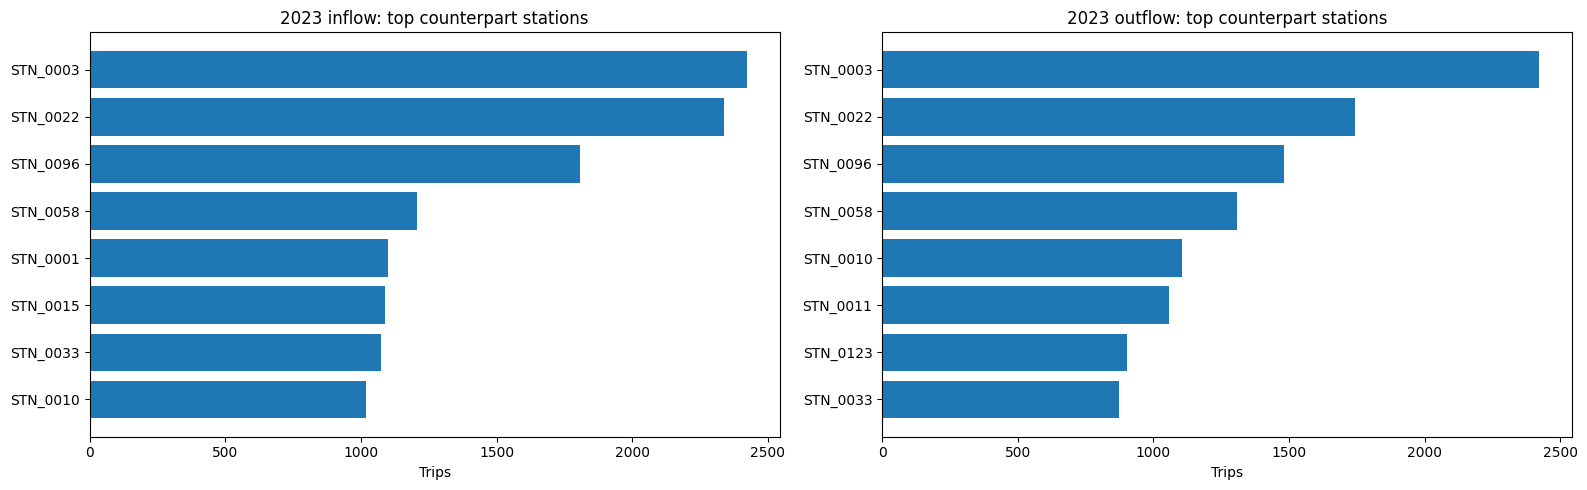

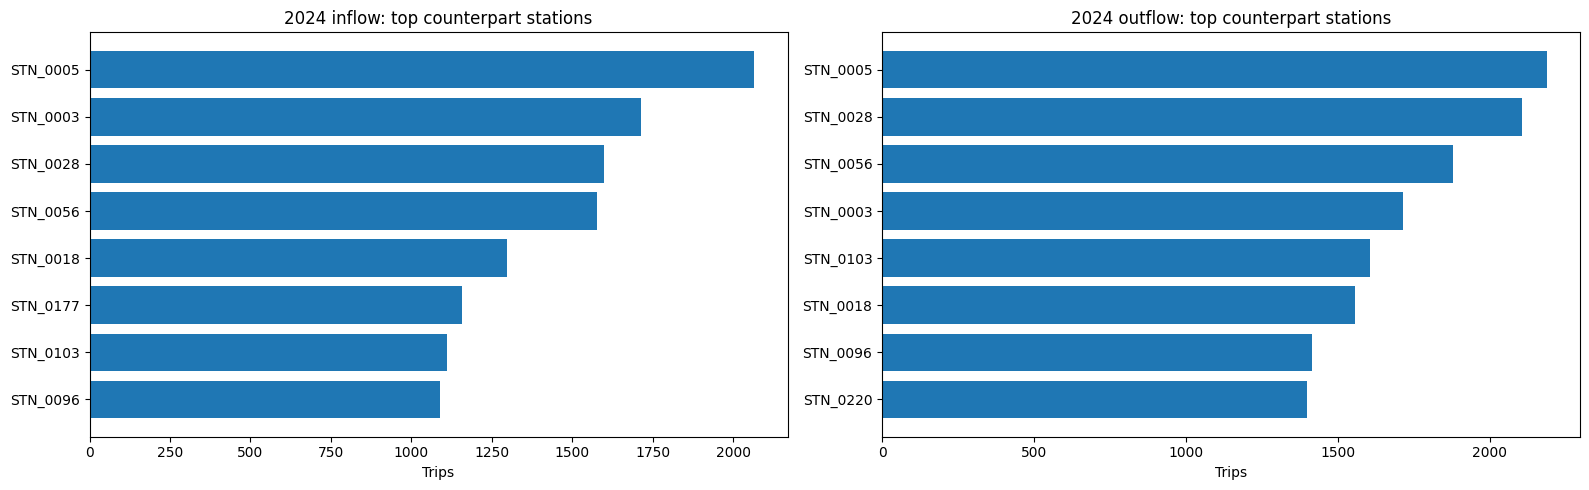

In [16]:
from pyspark.sql import functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt

TOP_N = 12

counterpart_year = (
    flow_df
    .groupBy("trip_year", "direction", "counterpart_station")
    .agg(F.count("*").alias("trip_count"))
)

window_y_d = Window.partitionBy("trip_year", "direction") \
                   .orderBy(F.desc("trip_count"), F.asc("counterpart_station"))

total_y_d = Window.partitionBy("trip_year", "direction")

counterpart_ranked = (
    counterpart_year
    .withColumn("rank", F.row_number().over(window_y_d))
    .withColumn("total_in_group", F.sum("trip_count").over(total_y_d))
    .withColumn("share", F.col("trip_count") / F.col("total_in_group"))
)

counterpart_top_pd = (
    counterpart_ranked
    .filter(F.col("rank") <= TOP_N)
    .orderBy("trip_year", "direction", "rank")
    .toPandas()
)

driver_concentration_pd = (
    counterpart_ranked
    .groupBy("trip_year", "direction")
    .agg(
        F.sum(F.when(F.col("rank") <= 5, F.col("trip_count")).otherwise(0)).alias("top5_trips"),
        F.max("total_in_group").alias("total_trips")
    )
    .withColumn("top5_share", F.col("top5_trips") / F.col("total_trips"))
    .orderBy("trip_year", "direction")
    .toPandas()
)

print("Top counterpart stations by year and direction:")
print(counterpart_top_pd.head(20))

print("\nConcentration of drivers (Top-5 share):")
print(driver_concentration_pd)

for y in ANALYSIS_YEARS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, d in zip(axes, ["inflow", "outflow"]):
        sub = (
            counterpart_top_pd[
                (counterpart_top_pd["trip_year"] == y) &
                (counterpart_top_pd["direction"] == d)
            ]
            .sort_values("rank")
            .head(8)
        )
        ax.barh(sub["counterpart_station"], sub["trip_count"])
        ax.invert_yaxis()
        ax.set_title(f"{y} {d}: top counterpart stations")
        ax.set_xlabel("Trips")
    plt.tight_layout()
    plt.show()

Peak-hour share metrics (7-9 and 16-18):
   trip_year direction  total_trips  am_peak_trips  pm_peak_trips  \
0       2023    inflow        66814           5757          17210   
1       2023   outflow        70239           6993          17176   
2       2024    inflow        71075          11210          18022   
3       2024   outflow        83672          11999          21163   

   am_peak_share  pm_peak_share  
0       0.086165       0.257581  
1       0.099560       0.244537  
2       0.157721       0.253563  
3       0.143405       0.252928  


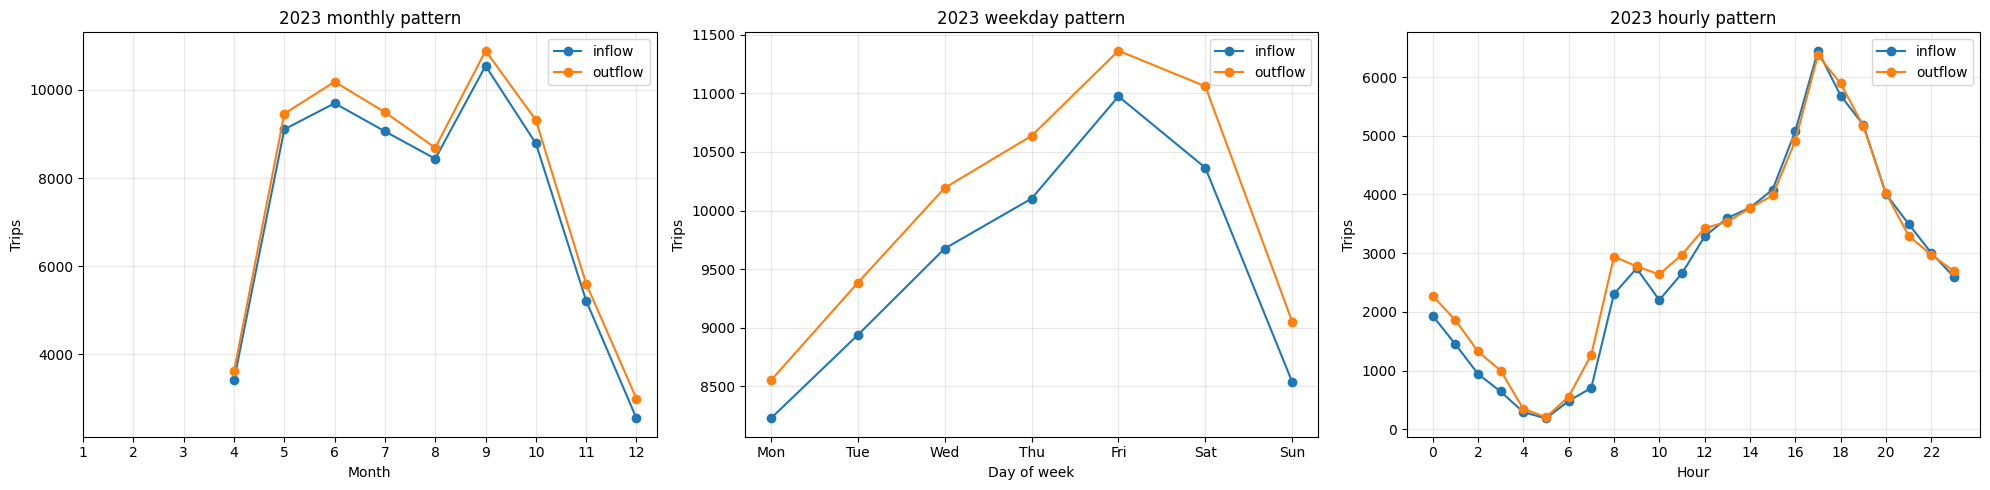

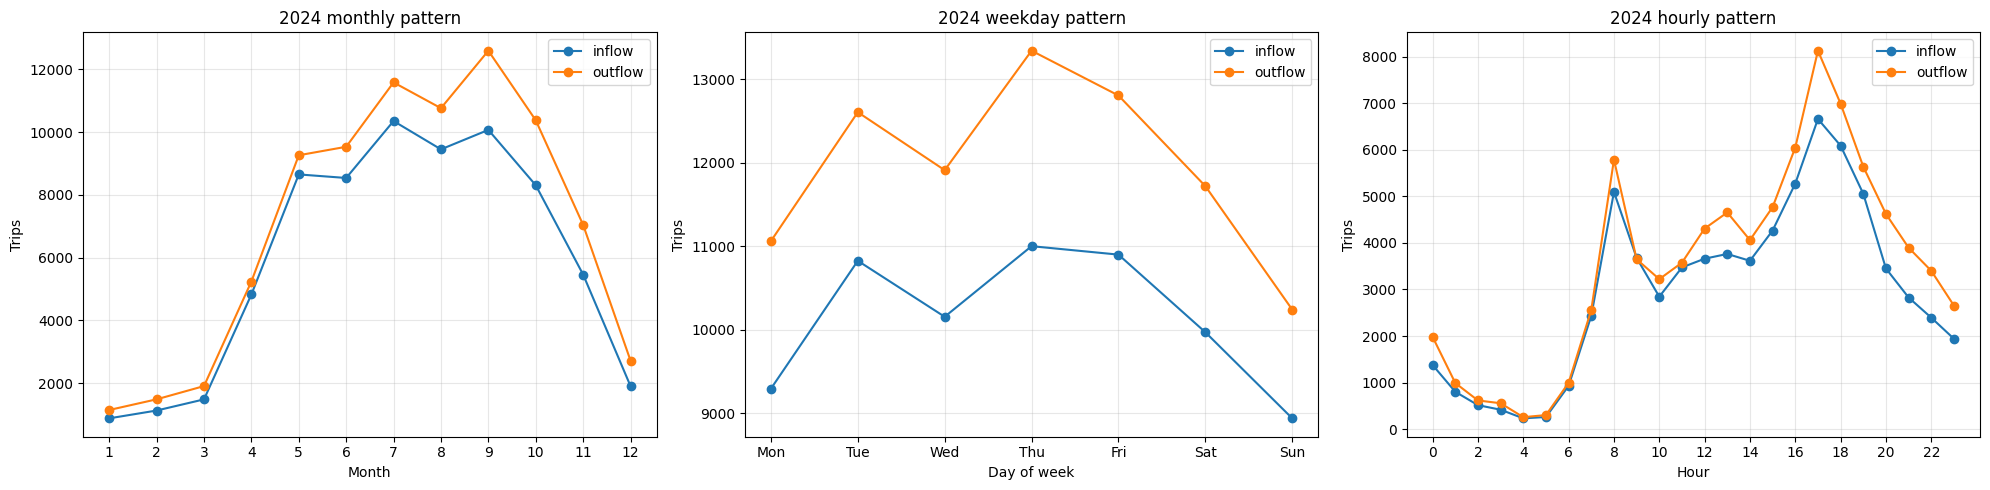


Largest monthly absolute changes based on abs_change_2024_vs_2023:
trip_year           2023     2024  abs_change_2024_vs_2023  \
direction month                                              
outflow   7       9491.0  11585.0                   2094.0   
          8       8686.0  10764.0                   2078.0   
          3          0.0   1909.0                   1909.0   
          9      10888.0  12595.0                   1707.0   
          4       3621.0   5241.0                   1620.0   
          2          0.0   1487.0                   1487.0   
inflow    3          0.0   1485.0                   1485.0   
outflow   11      5603.0   7046.0                   1443.0   
inflow    4       3421.0   4828.0                   1407.0   
          7       9058.0  10354.0                   1296.0   
outflow   1          0.0   1147.0                   1147.0   
inflow    2          0.0   1130.0                   1130.0   

trip_year        pct_change_2024_vs_2023  
direction month     

In [17]:
from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Task 3: Temporal drivers
# =========================

DIRECTIONS = ["inflow", "outflow"]
DOW_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def aggregate_temporal_counts(df, time_col, sort_cols=None, categorical_order=None):
    """
    Aggregate trip counts by year, direction, and a temporal column.
    Returns a pandas DataFrame.
    """
    pdf = (
        df.groupBy("trip_year", "direction", time_col)
          .agg(F.count("*").alias("trip_count"))
    )

    if sort_cols:
        pdf = pdf.orderBy(*sort_cols)

    pdf = pdf.toPandas()

    if categorical_order is not None:
        pdf[time_col] = pd.Categorical(
            pdf[time_col],
            categories=categorical_order,
            ordered=True
        )
        pdf = pdf.sort_values(["trip_year", "direction", time_col])

    return pdf


def compute_peak_metrics(df, am_range=(7, 9), pm_range=(16, 18)):
    """
    Compute AM and PM peak-hour shares by year and direction.
    """
    return (
        df.withColumn("is_am_peak", F.col("hour").between(*am_range).cast("int"))
          .withColumn("is_pm_peak", F.col("hour").between(*pm_range).cast("int"))
          .groupBy("trip_year", "direction")
          .agg(
              F.count("*").alias("total_trips"),
              F.sum("is_am_peak").alias("am_peak_trips"),
              F.sum("is_pm_peak").alias("pm_peak_trips")
          )
          .withColumn("am_peak_share", F.col("am_peak_trips") / F.col("total_trips"))
          .withColumn("pm_peak_share", F.col("pm_peak_trips") / F.col("total_trips"))
          .orderBy("trip_year", "direction")
          .toPandas()
    )


def plot_temporal_panel(year, monthly_pd, weekday_pd, hourly_pd, directions=DIRECTIONS):
    """
    Plot monthly, weekday, and hourly trip patterns for a given year.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    plot_specs = [
        {
            "data": monthly_pd,
            "x": "month",
            "title": f"{year} monthly pattern",
            "xlabel": "Month",
            "xticks": list(range(1, 13)),
            "ax": axes[0]
        },
        {
            "data": weekday_pd,
            "x": "day_of_week",
            "title": f"{year} weekday pattern",
            "xlabel": "Day of week",
            "xticks": None,
            "ax": axes[1]
        },
        {
            "data": hourly_pd,
            "x": "hour",
            "title": f"{year} hourly pattern",
            "xlabel": "Hour",
            "xticks": list(range(0, 24, 2)),
            "ax": axes[2]
        }
    ]

    for spec in plot_specs:
        sub = spec["data"][spec["data"]["trip_year"] == year]
        ax = spec["ax"]

        for d in directions:
            dsub = sub[sub["direction"] == d]
            ax.plot(dsub[spec["x"]], dsub["trip_count"], marker="o", label=d)

        ax.set_title(spec["title"])
        ax.set_xlabel(spec["xlabel"])
        ax.set_ylabel("Trips")
        if spec["xticks"] is not None:
            ax.set_xticks(spec["xticks"])
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


def compute_monthly_yoy(monthly_pd):
    """
    Compute year-over-year monthly changes for all adjacent available years.
    Returns pivoted monthly table with YoY metrics added where possible.
    """
    monthly_pivot = (
        monthly_pd.pivot_table(
            index=["direction", "month"],
            columns="trip_year",
            values="trip_count",
            aggfunc="sum"
        )
        .fillna(0)
    )

    years = sorted([c for c in monthly_pivot.columns if isinstance(c, (int, np.integer))])

    for prev_year, curr_year in zip(years[:-1], years[1:]):
        abs_col = f"abs_change_{curr_year}_vs_{prev_year}"
        pct_col = f"pct_change_{curr_year}_vs_{prev_year}"

        monthly_pivot[abs_col] = monthly_pivot[curr_year] - monthly_pivot[prev_year]
        monthly_pivot[pct_col] = np.where(
            monthly_pivot[prev_year] > 0,
            (monthly_pivot[curr_year] / monthly_pivot[prev_year]) - 1,
            np.nan
        )

    return monthly_pivot


# -------------------------
# Build temporal datasets
# -------------------------
monthly_pd = aggregate_temporal_counts(
    flow_df,
    time_col="month",
    sort_cols=["trip_year", "direction", "month"]
)

weekday_pd = aggregate_temporal_counts(
    flow_df,
    time_col="day_of_week",
    categorical_order=DOW_ORDER
)

hourly_pd = aggregate_temporal_counts(
    flow_df,
    time_col="hour",
    sort_cols=["trip_year", "direction", "hour"]
)

peak_metrics_pd = compute_peak_metrics(flow_df)

print("Peak-hour share metrics (7-9 and 16-18):")
print(peak_metrics_pd)

# -------------------------
# Plot yearly panels
# -------------------------
for y in ANALYSIS_YEARS:
    plot_temporal_panel(y, monthly_pd, weekday_pd, hourly_pd)

# -------------------------
# Year-over-year comparison
# -------------------------
monthly_yoy = compute_monthly_yoy(monthly_pd)

yoy_abs_cols = [c for c in monthly_yoy.columns if str(c).startswith("abs_change_")]
if yoy_abs_cols:
    latest_abs_col = yoy_abs_cols[-1]
    print(f"\nLargest monthly absolute changes based on {latest_abs_col}:")
    print(monthly_yoy.sort_values(latest_abs_col, ascending=False).head(12))

## visualise year x direction
### “At what time does demand concentrate?” (independent of total volume)

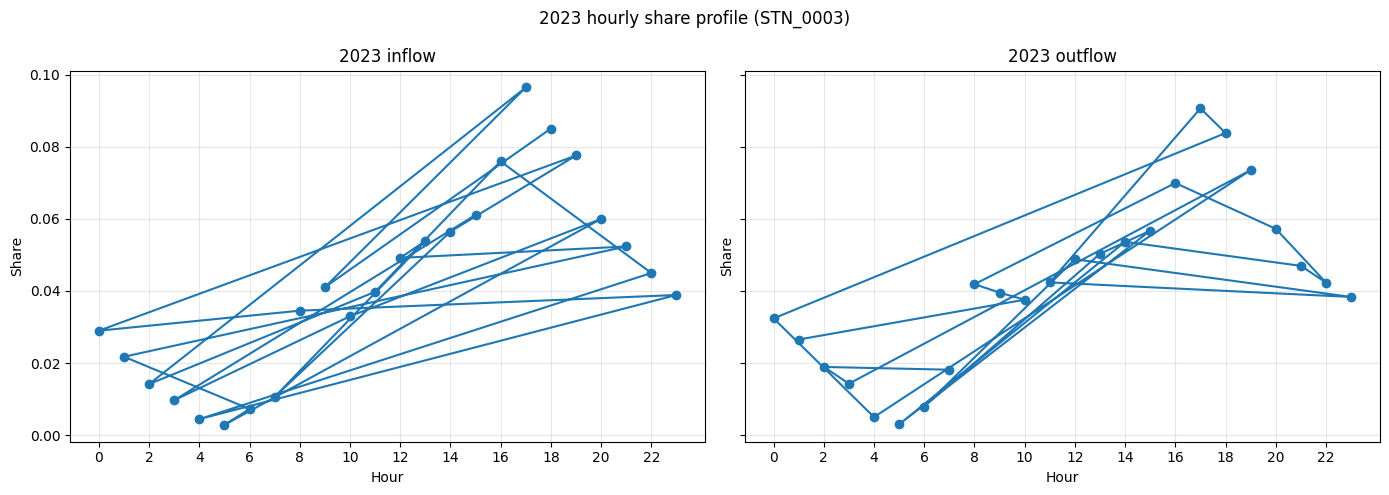

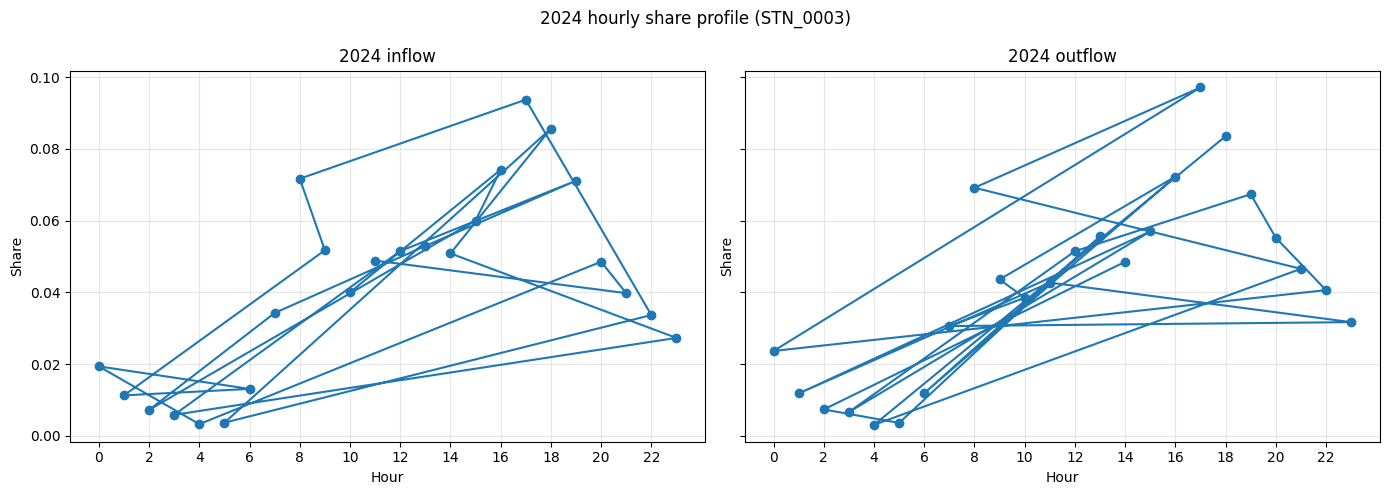

In [19]:
hourly_share_pd = (
    flow_df
    .groupBy("trip_year", "direction", "hour")
    .agg(F.count("*").alias("trip_count"))
    .toPandas()
)

# Normalize within each year × direction
hourly_share_pd["share"] = (
    hourly_share_pd["trip_count"] /
    hourly_share_pd.groupby(["trip_year", "direction"])["trip_count"].transform("sum")
)

# line chart
for y in ANALYSIS_YEARS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, d in zip(axes, ["inflow", "outflow"]):
        sub = hourly_share_pd[
            (hourly_share_pd["trip_year"] == y) &
            (hourly_share_pd["direction"] == d)
        ]

        ax.plot(sub["hour"], sub["share"], marker="o")
        ax.set_title(f"{y} {d}")
        ax.set_xlabel("Hour")
        ax.set_ylabel("Share")
        ax.set_xticks(range(0, 24, 2))
        ax.grid(alpha=0.3)

    plt.suptitle(f"{y} hourly share profile (STN_0003)")
    plt.tight_layout()
    plt.show()

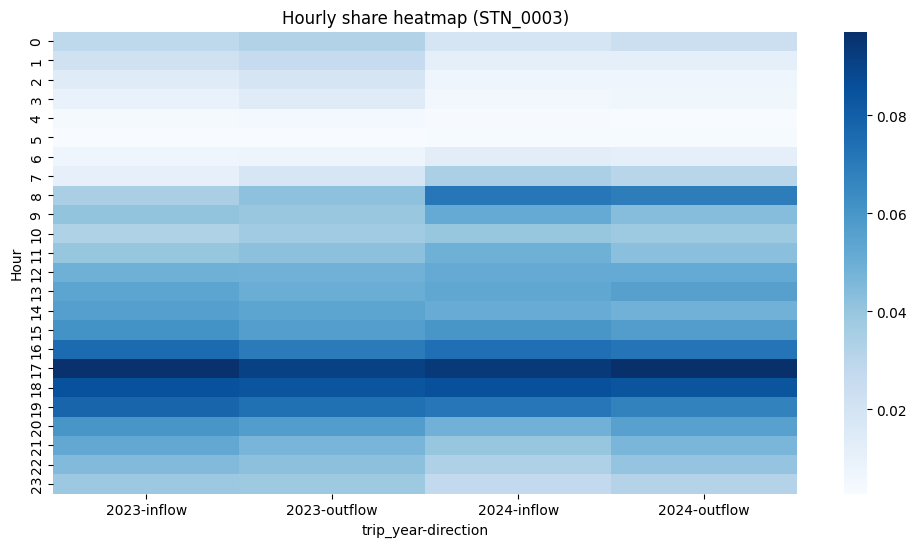

In [20]:
import seaborn as sns

pivot = hourly_share_pd.pivot_table(
    index="hour",
    columns=["trip_year", "direction"],
    values="share"
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="Blues")
plt.title("Hourly share heatmap (STN_0003)")
plt.ylabel("Hour")
plt.show()

- STN_0003 shows a strong bimodal pattern, with inflow peaking in the morning and outflow peaking in the evening — indicating a commuter-driven station.
- The hourly share is stable across years, suggesting consistent temporal behavior despite changes in total volume.
### Compared to raw counts, share highlights that the structure of demand remains unchanged.”

Peak-hour share metrics:
   trip_year direction  total_trips  am_peak_trips  pm_peak_trips  \
0       2023    inflow        66814           5757          17210   
1       2023   outflow        70239           6993          17176   
2       2024    inflow        71075          11210          18022   
3       2024   outflow        83672          11999          21163   

   am_peak_share  pm_peak_share  
0       0.086165       0.257581  
1       0.099560       0.244537  
2       0.157721       0.253563  
3       0.143405       0.252928  

Peak hour by year and direction:
    trip_year direction  peak_hour  peak_hour_share
93       2023    inflow         17         0.096507
31       2023   outflow         17         0.090705
57       2024    inflow         17         0.093718
19       2024   outflow         17         0.097117

Largest monthly absolute changes:
trip_year direction  month  prev_year  curr_year  abs_change  pct_change
18          outflow      7       2023       2024      209

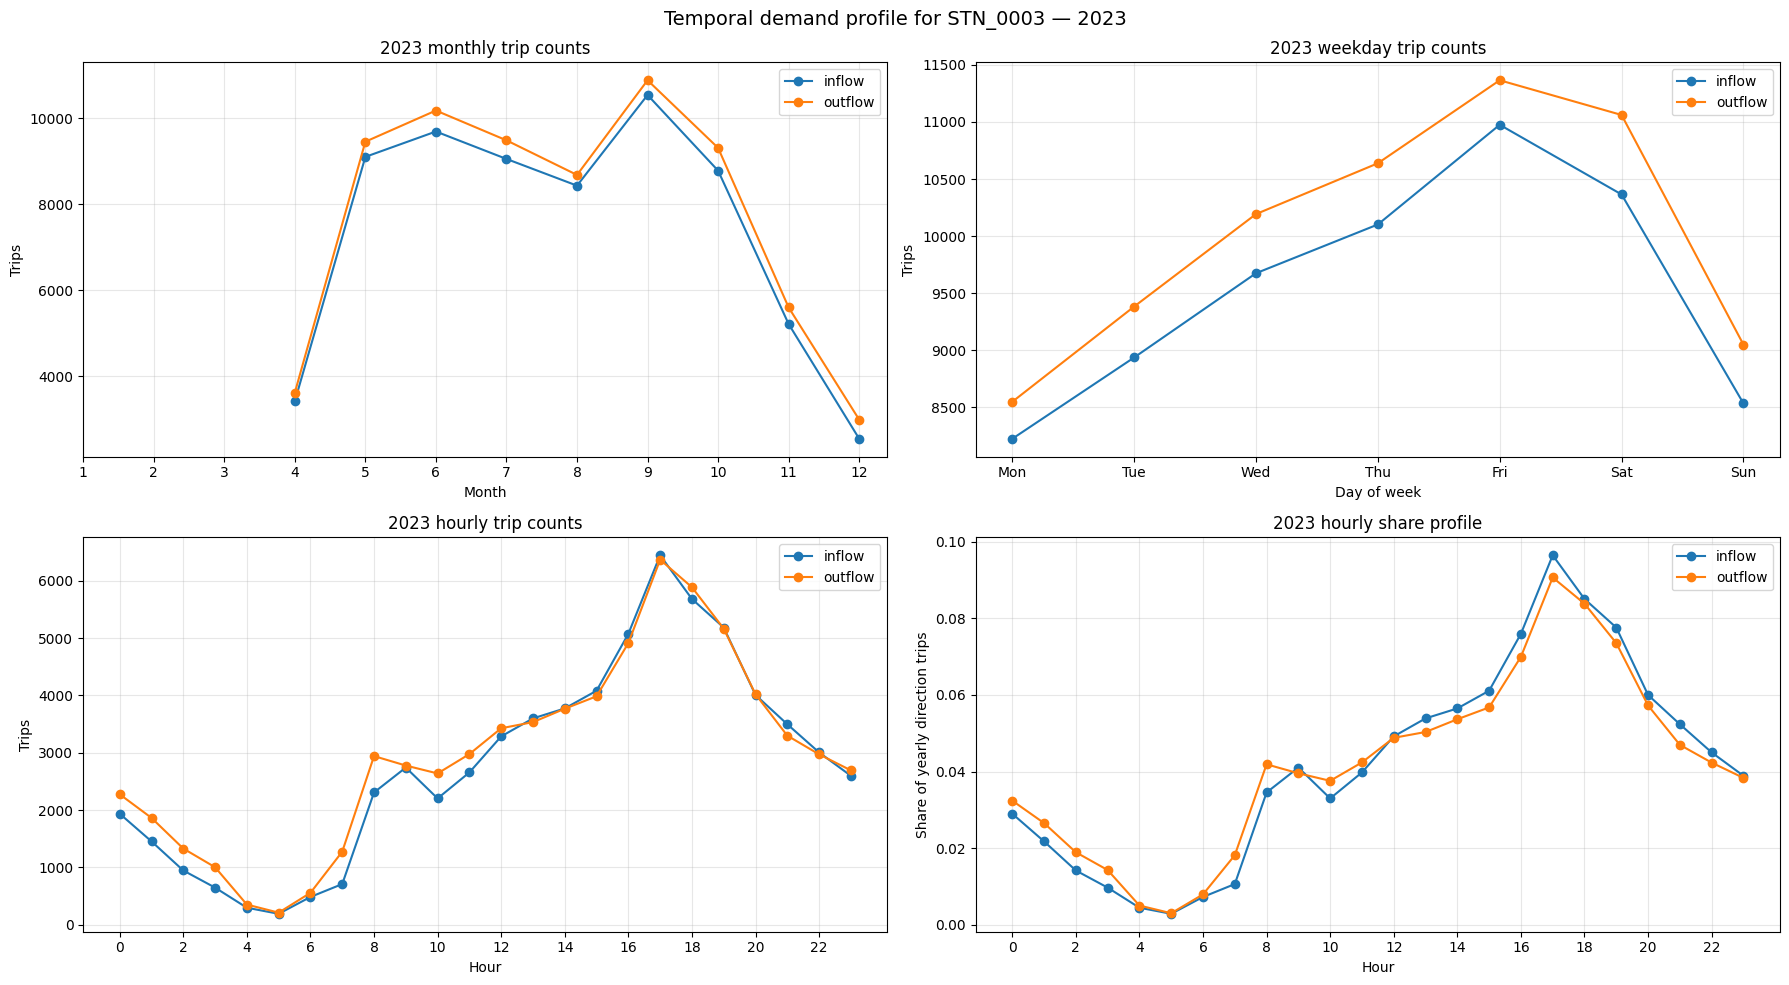

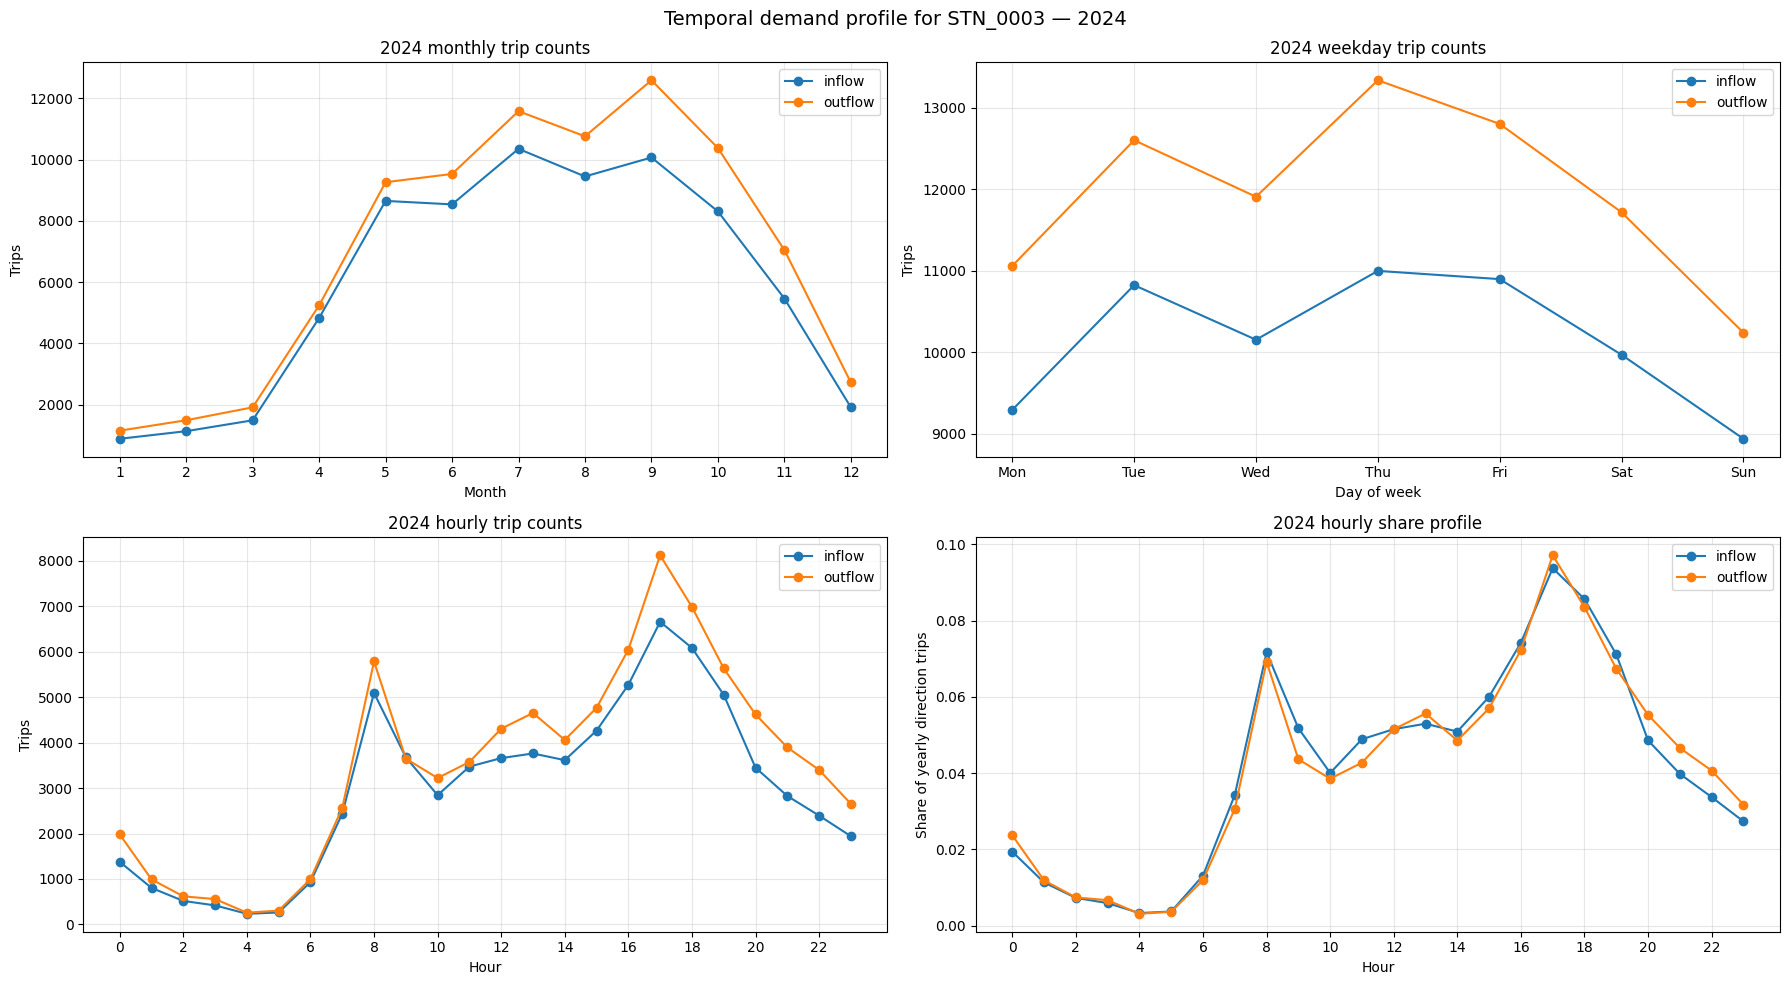

In [22]:
# extra task 3 on ==> Temporal drivers of STN_0003 demand

from pyspark.sql import functions as F
from pyspark.sql import Window
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Config
# -------------------------
DIRECTIONS = ["inflow", "outflow"]
DOW_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
AM_PEAK = (7, 9)
PM_PEAK = (16, 18)

# If not already defined, derive analysis years from the data
if "ANALYSIS_YEARS" not in globals():
    ANALYSIS_YEARS = sorted(
        [r["trip_year"] for r in flow_df.select("trip_year").distinct().orderBy("trip_year").collect()]
    )

# -------------------------
# Helper functions
# -------------------------
def aggregate_counts_to_pd(df, time_col, categorical_order=None):
    """
    Aggregate trip counts by trip_year, direction, and time_col.
    Returns a pandas DataFrame with trip_count.
    """
    pdf = (
        df.groupBy("trip_year", "direction", time_col)
          .agg(F.count("*").alias("trip_count"))
          .toPandas()
    )

    if categorical_order is not None:
        pdf[time_col] = pd.Categorical(
            pdf[time_col],
            categories=categorical_order,
            ordered=True
        )
        pdf = pdf.sort_values(["trip_year", "direction", time_col])
    else:
        pdf = pdf.sort_values(["trip_year", "direction", time_col])

    return pdf


def add_share_within_group(pdf, value_col="trip_count", group_cols=["trip_year", "direction"]):
    """
    Add share column normalized within group_cols.
    """
    pdf = pdf.copy()
    pdf["share"] = pdf[value_col] / pdf.groupby(group_cols)[value_col].transform("sum")
    return pdf


def compute_peak_metrics(df, am_peak=(7, 9), pm_peak=(16, 18)):
    """
    Compute AM/PM peak trip counts and shares.
    """
    return (
        df.withColumn("is_am_peak", F.col("hour").between(am_peak[0], am_peak[1]).cast("int"))
          .withColumn("is_pm_peak", F.col("hour").between(pm_peak[0], pm_peak[1]).cast("int"))
          .groupBy("trip_year", "direction")
          .agg(
              F.count("*").alias("total_trips"),
              F.sum("is_am_peak").alias("am_peak_trips"),
              F.sum("is_pm_peak").alias("pm_peak_trips")
          )
          .withColumn("am_peak_share", F.col("am_peak_trips") / F.col("total_trips"))
          .withColumn("pm_peak_share", F.col("pm_peak_trips") / F.col("total_trips"))
          .orderBy("trip_year", "direction")
          .toPandas()
    )


def compute_hourly_peak_rows(hourly_share_pd):
    """
    For each year and direction, find the hour with the highest share.
    """
    peak_idx = hourly_share_pd.groupby(["trip_year", "direction"])["share"].idxmax()
    peak_hours = hourly_share_pd.loc[peak_idx].copy()
    peak_hours = peak_hours.rename(columns={
        "hour": "peak_hour",
        "trip_count": "peak_hour_trip_count",
        "share": "peak_hour_share"
    })
    return peak_hours.sort_values(["trip_year", "direction"])


def plot_year_temporal_dashboard(year, monthly_pd, weekday_pd, hourly_pd, hourly_share_pd):
    """
    4-panel dashboard for one year:
    1) Monthly counts
    2) Weekday counts
    3) Hourly counts
    4) Hourly share
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    # ---- Monthly counts
    sub = monthly_pd[monthly_pd["trip_year"] == year]
    for d in DIRECTIONS:
        dsub = sub[sub["direction"] == d]
        axes[0].plot(dsub["month"], dsub["trip_count"], marker="o", label=d)
    axes[0].set_title(f"{year} monthly trip counts")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Trips")
    axes[0].set_xticks(range(1, 13))
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # ---- Weekday counts
    sub = weekday_pd[weekday_pd["trip_year"] == year]
    for d in DIRECTIONS:
        dsub = sub[sub["direction"] == d]
        axes[1].plot(dsub["day_of_week"].astype(str), dsub["trip_count"], marker="o", label=d)
    axes[1].set_title(f"{year} weekday trip counts")
    axes[1].set_xlabel("Day of week")
    axes[1].set_ylabel("Trips")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    # ---- Hourly counts
    sub = hourly_pd[hourly_pd["trip_year"] == year]
    for d in DIRECTIONS:
        dsub = sub[sub["direction"] == d]
        axes[2].plot(dsub["hour"], dsub["trip_count"], marker="o", label=d)
    axes[2].set_title(f"{year} hourly trip counts")
    axes[2].set_xlabel("Hour")
    axes[2].set_ylabel("Trips")
    axes[2].set_xticks(range(0, 24, 2))
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    # ---- Hourly share
    sub = hourly_share_pd[hourly_share_pd["trip_year"] == year]
    for d in DIRECTIONS:
        dsub = sub[sub["direction"] == d]
        axes[3].plot(dsub["hour"], dsub["share"], marker="o", label=d)
    axes[3].set_title(f"{year} hourly share profile")
    axes[3].set_xlabel("Hour")
    axes[3].set_ylabel("Share of yearly direction trips")
    axes[3].set_xticks(range(0, 24, 2))
    axes[3].grid(alpha=0.3)
    axes[3].legend()

    plt.suptitle(f"Temporal demand profile for STN_0003 — {year}", fontsize=14)
    plt.tight_layout()
    plt.show()


def compute_monthly_yoy(monthly_pd):
    """
    Compute YoY changes for monthly trips for each direction.
    """
    monthly_pivot = (
        monthly_pd.pivot_table(
            index=["direction", "month"],
            columns="trip_year",
            values="trip_count",
            aggfunc="sum"
        )
        .fillna(0)
    )

    years = sorted([c for c in monthly_pivot.columns if isinstance(c, (int, np.integer))])

    yoy_outputs = []
    for prev_year, curr_year in zip(years[:-1], years[1:]):
        temp = monthly_pivot.copy()
        temp["prev_year"] = prev_year
        temp["curr_year"] = curr_year
        temp["abs_change"] = temp[curr_year] - temp[prev_year]
        temp["pct_change"] = np.where(
            temp[prev_year] > 0,
            (temp[curr_year] / temp[prev_year]) - 1,
            np.nan
        )
        yoy_outputs.append(temp.reset_index())

    if len(yoy_outputs) == 0:
        return None

    return pd.concat(yoy_outputs, ignore_index=True)


# -------------------------
# Build temporal datasets
# -------------------------
monthly_pd = aggregate_counts_to_pd(flow_df, "month")
weekday_pd = aggregate_counts_to_pd(flow_df, "day_of_week", categorical_order=DOW_ORDER)
hourly_pd = aggregate_counts_to_pd(flow_df, "hour")

# Share-based hourly profile
hourly_share_pd = add_share_within_group(hourly_pd, value_col="trip_count")

# Compact metrics
peak_metrics_pd = compute_peak_metrics(flow_df, am_peak=AM_PEAK, pm_peak=PM_PEAK)
peak_hour_pd = compute_hourly_peak_rows(hourly_share_pd)

# YoY monthly changes
monthly_yoy_pd = compute_monthly_yoy(monthly_pd)

# -------------------------
# Print summary tables
# -------------------------
print("Peak-hour share metrics:")
print(peak_metrics_pd)

print("\nPeak hour by year and direction:")
print(peak_hour_pd[["trip_year", "direction", "peak_hour", "peak_hour_share"]])

if monthly_yoy_pd is not None:
    print("\nLargest monthly absolute changes:")
    print(
        monthly_yoy_pd.sort_values("abs_change", ascending=False)[
            ["direction", "month", "prev_year", "curr_year", "abs_change", "pct_change"]
        ].head(12)
    )

# -------------------------
# Plot dashboards by year
# -------------------------
for y in ANALYSIS_YEARS:
    plot_year_temporal_dashboard(
        year=y,
        monthly_pd=monthly_pd,
        weekday_pd=weekday_pd,
        hourly_pd=hourly_pd,
        hourly_share_pd=hourly_share_pd
    )

Monthly coverage-adjusted view (first rows):
    trip_year direction  month  trip_count  active_days  trips_per_active_day
0        2023    inflow      4        3421           19            180.052632
1        2023    inflow      5        9106           31            293.741935
2        2023    inflow      6        9696           30            323.200000
3        2023    inflow      7        9058           31            292.193548
4        2023    inflow      8        8437           31            272.161290
5        2023    inflow      9       10545           30            351.500000
6        2023    inflow     10        8785           31            283.387097
7        2023    inflow     11        5217           30            173.900000
8        2023    inflow     12        2549           31             82.225806
9        2023   outflow      4        3621           19            190.578947
10       2023   outflow      5        9459           31            305.129032
11       2023   out

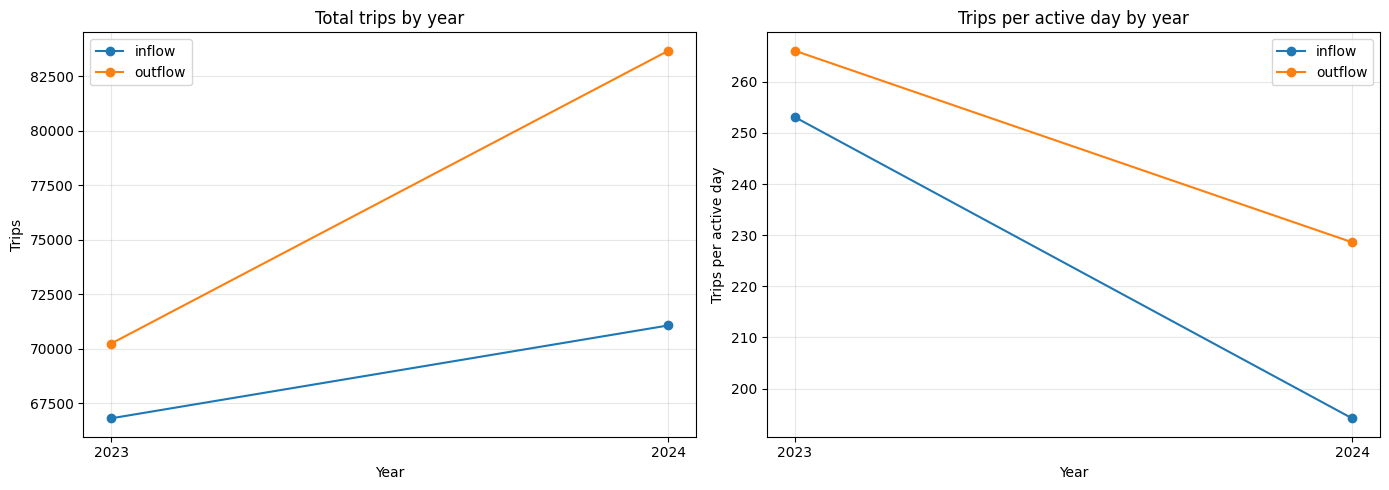

In [21]:
# Task 4: Coverage check (active days) to avoid mistaking partial data for demand shifts
coverage_pd = (
    flow_df
    .withColumn("event_date", F.to_date("event_ts"))
    .groupBy("trip_year", "direction", "month")
    .agg(
        F.count("*").alias("trip_count"),
        F.countDistinct("event_date").alias("active_days")
    )
    .withColumn("trips_per_active_day", F.col("trip_count") / F.col("active_days"))
    .orderBy("trip_year", "direction", "month")
    .toPandas()
)

print("Monthly coverage-adjusted view (first rows):")
print(coverage_pd.head(18))

year_cov_pd = (
    coverage_pd
    .groupby(["trip_year", "direction"], as_index=False)
    .agg(
        trip_count=("trip_count", "sum"),
        active_days=("active_days", "sum")
    )
)
year_cov_pd["trips_per_active_day"] = year_cov_pd["trip_count"] / year_cov_pd["active_days"]
print("\nYear-level coverage-adjusted summary:")
print(year_cov_pd)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for d in ["inflow", "outflow"]:
    sub = year_cov_pd[year_cov_pd["direction"] == d]
    axes[0].plot(sub["trip_year"].astype(str), sub["trip_count"], marker="o", label=d)
    axes[1].plot(sub["trip_year"].astype(str), sub["trips_per_active_day"], marker="o", label=d)

axes[0].set_title("Total trips by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Trips")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Trips per active day by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Trips per active day")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### check for missing-mapping 

In [24]:
# Missing-mapping investigation for STN_0003
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

station_cleaning_root = "../../data/silver/station_cleaning"
station_summary_path = f"{station_cleaning_root}/station_canonical_summary"
station_mapping_path = f"{station_cleaning_root}/station_direct_match_mapping"

station_summary_df = spark.read.parquet(station_summary_path)
mapping_df = spark.read.parquet(station_mapping_path)

# Canonical coordinates
station_meta_pd = (
    station_summary_df
    .select(
        F.col("canonical_station_id").alias("station_id"),
        F.col("canonical_lat").alias("lat"),
        F.col("canonical_lon").alias("lon")
    )
    .dropDuplicates(["station_id"])
    .toPandas()
)

# Pull best available station name
candidate_name_cols = [
    "normalized_name",
    "canonical_station_name_norm",
    "canonical_name_norm",
    "station_name_norm",
    "canonical_station_name",
    "canonical_name",
    "station_name",
]
available_name_cols = [c for c in candidate_name_cols if c in mapping_df.columns]

if "canonical_station_id" in mapping_df.columns and available_name_cols:
    name_df = mapping_df.groupBy("canonical_station_id").agg(
        *[F.first(F.col(c), ignorenulls=True).alias(c) for c in available_name_cols]
    )
    name_pd = name_df.toPandas().rename(columns={"canonical_station_id": "station_id"})
else:
    name_pd = station_meta_pd[["station_id"]].copy()

station_meta_pd = station_meta_pd.merge(name_pd, on="station_id", how="left")

name_norm_col = next(
    (c for c in ["normalized_name", "canonical_station_name_norm", "canonical_name_norm", "station_name_norm"]
     if c in station_meta_pd.columns),
    None
)
name_col = next(
    (c for c in ["canonical_station_name", "canonical_name", "station_name"]
     if c in station_meta_pd.columns),
    None
)

station_meta_pd["name"] = (
    station_meta_pd[name_col].astype(str) if name_col else station_meta_pd["station_id"].astype(str)
)
station_meta_pd["name_norm"] = (
    station_meta_pd[name_norm_col].astype(str).str.lower().str.strip()
    if name_norm_col else station_meta_pd["name"].astype(str).str.lower().str.strip()
)

station_meta_pd = station_meta_pd.dropna(subset=["station_id", "lat", "lon"]).copy()
station_meta_pd["station_id"] = station_meta_pd["station_id"].astype(str)

target_meta = station_meta_pd[station_meta_pd["station_id"] == TARGET_STATION]
if target_meta.empty:
    raise RuntimeError(f"{TARGET_STATION} not found in station metadata")

t = target_meta.iloc[0]

# Haversine distance (km)
r_earth = 6371.0
lat1 = np.radians(float(t["lat"]))
lon1 = np.radians(float(t["lon"]))
lat2 = np.radians(station_meta_pd["lat"].astype(float))
lon2 = np.radians(station_meta_pd["lon"].astype(float))

dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dlon / 2) ** 2)
station_meta_pd["distance_km"] = 2 * r_earth * np.arcsin(np.sqrt(a))

target_name_norm = str(t["name_norm"] or "").lower().strip()

def text_sim(s):
    s = str(s or "").lower().strip()
    if not target_name_norm or not s or s == "none":
        return 0.0
    return SequenceMatcher(None, target_name_norm, s).ratio()

station_meta_pd["name_similarity"] = station_meta_pd["name_norm"].apply(text_sim)

# Prefer very local stations more strongly
station_meta_pd["geo_similarity"] = 1.0 / (1.0 + station_meta_pd["distance_km"])

# Slightly more balanced than original
station_meta_pd["similarity_score"] = (
    0.65 * station_meta_pd["geo_similarity"] +
    0.35 * station_meta_pd["name_similarity"]
)

candidate_ranked_geo_name = (
    station_meta_pd[
        (station_meta_pd["station_id"] != TARGET_STATION) &
        (station_meta_pd["distance_km"] <= 0.5)   # <= 500m
    ]
    .sort_values(["similarity_score", "distance_km", "name_similarity"], ascending=[False, True, False])
    .reset_index(drop=True)
)

print(f"Target station metadata for {TARGET_STATION}:")
print(t[["station_id", "name", "name_norm", "lat", "lon"]])

print("\nTop 15 nearby/name-similar candidates:")
print(candidate_ranked_geo_name[
    ["station_id", "name", "distance_km", "name_similarity", "similarity_score"]
].head(15))

Target station metadata for STN_0003:
station_id              STN_0003
name                    STN_0003
name_norm     laurier / st-denis
lat                    45.527154
lon                   -73.589439
Name: 1002, dtype: object

Top 15 nearby/name-similar candidates:
   station_id      name  distance_km  name_similarity  similarity_score
0    STN_0206  STN_0206     0.211516         0.549020          0.728675
1    STN_0089  STN_0089     0.130894         0.424242          0.723251
2    STN_0040  STN_0040     0.385493         0.722222          0.721925
3    STN_0201  STN_0201     0.171347         0.350000          0.677417
4    STN_0341  STN_0341     0.314344         0.500000          0.669543
5    STN_1025  STN_1025     0.396368         0.555556          0.659938
6    STN_0141  STN_0141     0.232948         0.378378          0.659624
7    STN_0696  STN_0696     0.342444         0.450000          0.641692
8    STN_0123  STN_0123     0.266483         0.363636          0.640505
9    STN_07

In [25]:
# Build monthly station-touch counts safely using as_timestamp()
all_out = (
    rides_df
    .filter(F.col("ride_year").isin(ANALYSIS_YEARS))
    .select(
        F.col("ride_year").alias("trip_year"),
        F.month(as_timestamp("start_time_ms")).alias("month"),
        F.col("start_canonical_station_id").alias("station_id")
    )
)

all_in = (
    rides_df
    .filter(F.col("ride_year").isin(ANALYSIS_YEARS))
    .select(
        F.col("ride_year").alias("trip_year"),
        F.month(as_timestamp("end_time_ms")).alias("month"),
        F.col("end_canonical_station_id").alias("station_id")
    )
)

all_station_month = (
    all_out
    .unionByName(all_in)
    .filter(F.col("station_id").isNotNull() & F.col("month").isNotNull())
    .groupBy("trip_year", "month", "station_id")
    .agg(F.count("*").alias("touch_trips"))
    .cache()
)

display(all_station_month.orderBy("trip_year", "month", "station_id").limit(10))

DataFrame[trip_year: int, month: int, station_id: string, touch_trips: bigint]

In [26]:
# Detect target weak / missing months in 2023
target_2023_pd = (
    all_station_month
    .filter((F.col("trip_year") == 2023) & (F.col("station_id") == TARGET_STATION))
    .select("month", "touch_trips")
    .toPandas()
)

target_2023_series = pd.Series(0.0, index=range(1, 13))
if not target_2023_pd.empty:
    target_2023_series.loc[target_2023_pd["month"].astype(int)] = target_2023_pd["touch_trips"].astype(float).values

# Define weak months as zero OR bottom quartile
positive_vals = target_2023_series[target_2023_series > 0]
weak_threshold = positive_vals.quantile(0.25) if len(positive_vals) > 0 else 0.0
weak_months = [m for m in range(1, 13) if target_2023_series.loc[m] <= weak_threshold]

print(f"Weak / suspected gap months for {TARGET_STATION} in 2023:", weak_months)

candidate_ids = candidate_ranked_geo_name["station_id"].head(80).tolist()

cand_month_pd = (
    all_station_month
    .filter((F.col("trip_year") == 2023) & F.col("station_id").isin(candidate_ids + [TARGET_STATION]))
    .toPandas()
)

# Complete monthly grid
rows = []
for sid in candidate_ids + [TARGET_STATION]:
    sub = cand_month_pd[cand_month_pd["station_id"] == sid]
    month_map = dict(zip(sub["month"].astype(int), sub["touch_trips"].astype(float)))
    for m in range(1, 13):
        rows.append({
            "station_id": sid,
            "month": m,
            "touch_trips": month_map.get(m, 0.0)
        })

full_2023_pd = pd.DataFrame(rows)

sim_lookup = candidate_ranked_geo_name.set_index("station_id")

# Score candidates
score_rows = []
target_nonweak_months = [m for m in range(1, 13) if m not in weak_months]

for sid in candidate_ids:
    s = full_2023_pd[full_2023_pd["station_id"] == sid].set_index("month")["touch_trips"]

    weak_fill = float(s.loc[weak_months].sum()) if weak_months else 0.0
    nonweak_fill = float(s.loc[target_nonweak_months].sum()) if target_nonweak_months else 0.0

    # Candidate should be relatively stronger when target is weak
    replacement_ratio = weak_fill / max(weak_fill + nonweak_fill, 1.0)

    # Candidate should fade when target recovers later
    if len(weak_months) > 0 and max(weak_months) < 12:
        post_window = list(range(max(weak_months) + 1, 13))
        candidate_post = float(s.loc[post_window].sum()) if post_window else 0.0
        fade_score = max((weak_fill - candidate_post) / max(weak_fill, 1.0), 0.0)
    else:
        fade_score = 0.0

    sim_score = float(sim_lookup.loc[sid, "similarity_score"]) if sid in sim_lookup.index else 0.0
    dist_km = float(sim_lookup.loc[sid, "distance_km"]) if sid in sim_lookup.index else np.nan

    score_rows.append({
        "station_id": sid,
        "distance_km": dist_km,
        "weak_fill_trips": weak_fill,
        "nonweak_fill_trips": nonweak_fill,
        "replacement_ratio": replacement_ratio,
        "fade_score": fade_score,
        "similarity_score": sim_score
    })

candidate_gap_pd = pd.DataFrame(score_rows)

candidate_gap_pd["replacement_norm"] = candidate_gap_pd["replacement_ratio"] / max(candidate_gap_pd["replacement_ratio"].max(), 1.0)
candidate_gap_pd["fade_norm"] = candidate_gap_pd["fade_score"] / max(candidate_gap_pd["fade_score"].max(), 1.0)
candidate_gap_pd["sim_norm"] = candidate_gap_pd["similarity_score"] / max(candidate_gap_pd["similarity_score"].max(), 1.0)

candidate_gap_pd["gap_candidate_score"] = (
    0.50 * candidate_gap_pd["replacement_norm"] +
    0.25 * candidate_gap_pd["fade_norm"] +
    0.25 * candidate_gap_pd["sim_norm"]
)

candidate_gap_ranked = candidate_gap_pd.sort_values(
    ["gap_candidate_score", "replacement_ratio", "fade_score", "distance_km"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("Top candidates for possible STN_0003 handoff / mis-mapping:")
print(candidate_gap_ranked.head(15))

Weak / suspected gap months for STN_0003 in 2023: [1, 2, 3, 4, 11, 12]
Top candidates for possible STN_0003 handoff / mis-mapping:
   station_id  distance_km  weak_fill_trips  nonweak_fill_trips  \
0    STN_0652     0.304639           8782.0             28261.0   
1    STN_0040     0.385493           9647.0             60060.0   
2    STN_0252     0.443926           2763.0             11056.0   
3    STN_0089     0.130894           6107.0             48659.0   
4    STN_0206     0.211516           3021.0             32015.0   
5    STN_0123     0.266483          10737.0             71781.0   
6    STN_0617     0.330436           1484.0             10837.0   
7    STN_0762     0.296021            963.0              8172.0   
8    STN_0341     0.314344           2169.0             23209.0   
9    STN_0827     0.463821            773.0              6915.0   
10   STN_0696     0.342444           2681.0             30290.0   
11   STN_0857     0.286581           1281.0             12497.0  

#### major idea bumps
- use as_timestamp() for month extraction
- restrict candidates to nearby stations first, instead of ranking the whole system
- detect weak months dynamically instead of hardcoding a Jan–Jun / Jul–Dec split
- score “replacement pattern” directly, not just pre/post drop

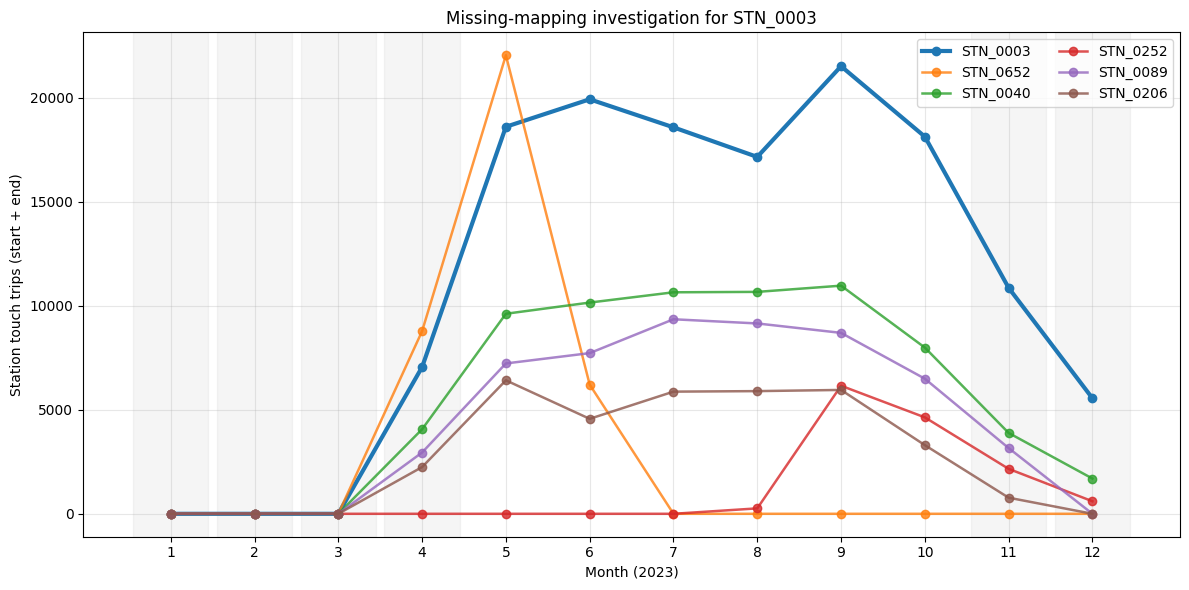

In [ ]:
# Plot target vs top 5 candidates in 2023
top5 = candidate_gap_ranked.head(5)["station_id"].tolist()
plot_ids = [TARGET_STATION] + top5
plot_pd = full_2023_pd[full_2023_pd["station_id"].isin(plot_ids)].copy()

plt.figure(figsize=(12, 6))
for sid in plot_ids:
    s = plot_pd[plot_pd["station_id"] == sid]
    lw = 3 if sid == TARGET_STATION else 1.8
    alpha = 1.0 if sid == TARGET_STATION else 0.8
    plt.plot(s["month"], s["touch_trips"], marker="o", linewidth=lw, alpha=alpha, label=sid)

for m in weak_months:
    plt.axvspan(m - 0.45, m + 0.45, color="gray", alpha=0.08)

plt.xticks(range(1, 13))
plt.xlabel("Month (2023)")
plt.ylabel("Station touch trips (start + end)")
plt.title(f"Missing-mapping investigation for {TARGET_STATION}")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

"""
STN_0652 likely represents the same physical station as STN_0003 during early 2023. 
STN_0652 exhibits high activity precisely during the months when STN_0003 has zero recorded trips, 
and then abruptly drops to zero when STN_0003 becomes active. 
This inverse and discontinuous pattern strongly suggests a station ID remapping or data recording transition, 
rather than a genuine change in user demand.
"""

### STN_0652 is the smoking gun 🔥

Look at the orange line (STN_0652):
Month 4 → high (~9k)
Month 5 → very high (~22k peak)
Then → drops to zero immediately from month 7 onward

Period	STN_0652	STN_0003

Early months	HIGH	ZERO

Later months	ZERO	HIGH

##### This is a perfect inverse relationship

This is classic station ID remapping / data handoff behavior:

STN_0652 was likely used to represent the same physical station as STN_0003 in early 2023, before the system switched to STN_0003.

📊 Supporting evidence
✔️ 1. Temporal substitution
STN_0652 is active exactly when STN_0003 is missing
Then disappears when STN_0003 appears
✔️ 2. Sharp discontinuity (not gradual)
Not a smooth decline → hard cutoff
Indicates system change, not behavioral change
✔️ 3. No other station behaves like this
Other candidates (0040, 0089, 0206, 0252):
Continue across months
Show normal seasonal patterns
Only 0652 shows a “takeover → disappear” pattern

#### 🧠 What about the other stations?
STN_0040 / STN_0089 / STN_0206
Smooth seasonal curves
Likely nearby but distinct stations
Not replacements
STN_0252
Only appears later (months 9–12)
Not aligned with missing period
Not relevant for mapping issue


In [ ]:
# naive time series modeling on STN_0003 would underestimate early-year demand 
# unless the historical data from STN_0652 is consolidated. Therefore, 
# correcting for this mapping issue is critical before performing forecasting or temporal trend analysis.

In [28]:
# =========================================================
# Task 3: Validate handoff pattern for STN_0003
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_STATION = "STN_0003"

# -------------------------
# Step 1: Prepare 2023 + 2024 monthly data
# -------------------------

cand_top_ids = candidate_gap_ranked.head(12)["station_id"].tolist()
check_ids = cand_top_ids + [TARGET_STATION]

# ---- 2024 data
cand_2024_pd = (
    all_station_month
    .filter((F.col("trip_year") == 2024) & F.col("station_id").isin(check_ids))
    .toPandas()
)

# Build full 12-month grid for 2024
rows_2024 = []
for sid in check_ids:
    sub = cand_2024_pd[cand_2024_pd["station_id"] == sid]
    month_map = dict(zip(sub["month"].astype(int), sub["touch_trips"].astype(float)))
    for m in range(1, 13):
        rows_2024.append({
            "station_id": sid,
            "month": m,
            "touch_trips": month_map.get(m, 0.0)
        })

full_2024_pd = pd.DataFrame(rows_2024)

# ---- 2023 target baseline
target_2023 = (
    full_2023_pd[full_2023_pd["station_id"] == TARGET_STATION]
    .set_index("month")["touch_trips"]
)

target_h1 = float(target_2023.loc[1:6].sum())
target_h2 = float(target_2023.loc[7:12].sum())

target_rise = (target_h2 - target_h1) / max(target_h1, 1.0)

# -------------------------
# Step 2: Compute handoff metrics
# -------------------------

handoff_rows = []

for sid in cand_top_ids:

    s23 = (
        full_2023_pd[full_2023_pd["station_id"] == sid]
        .set_index("month")["touch_trips"]
    )

    s24 = (
        full_2024_pd[full_2024_pd["station_id"] == sid]
        .set_index("month")["touch_trips"]
    )

    # ---- H1 vs H2 volumes
    cand_h1 = float(s23.loc[1:6].sum())
    cand_h2 = float(s23.loc[7:12].sum())

    # ---- Candidate drop after June
    cand_drop = (cand_h1 - cand_h2) / cand_h1 if cand_h1 > 0 else 0.0

    # ---- 2024 persistence (should be low for true handoff)
    cand_2024_total = float(s24.sum())

    # ---- Inverse correlation (CRITICAL SIGNAL)
    t_vals = target_2023.loc[1:12].values
    c_vals = s23.loc[1:12].values

    if np.std(t_vals) > 0 and np.std(c_vals) > 0:
        corr = np.corrcoef(t_vals, c_vals)[0, 1]
    else:
        corr = 0.0

    inverse_corr = max(-corr, 0)  # strong if negative

    # ---- Final handoff score
    handoff_score = (
        0.4 * max(cand_drop, 0) +
        0.3 * max(target_rise, 0) +
        0.3 * inverse_corr
    )

    # Penalize if candidate is still active in 2024
    if cand_2024_total > 0:
        handoff_score *= 0.5

    handoff_rows.append({
        "station_id": sid,
        "cand_h1_2023": cand_h1,
        "cand_h2_2023": cand_h2,
        "cand_drop_ratio": cand_drop,
        "inverse_corr_with_target": inverse_corr,
        "cand_2024_total": cand_2024_total,
        "handoff_score": handoff_score
    })

handoff_pd = (
    pd.DataFrame(handoff_rows)
    .sort_values("handoff_score", ascending=False)
    .reset_index(drop=True)
)

# -------------------------
# Step 3: Show ranking
# -------------------------

print("Handoff validation ranking (higher = stronger evidence):")
display(
    handoff_pd[
        [
            "station_id",
            "cand_drop_ratio",
            "inverse_corr_with_target",
            "cand_2024_total",
            "handoff_score"
        ]
    ].head(10)
)

best_handoff_station = handoff_pd.iloc[0]["station_id"]

print(f"\nBest handoff candidate: {best_handoff_station}")

Handoff validation ranking (higher = stronger evidence):


,station_id,cand_drop_ratio,inverse_corr_with_target,cand_2024_total,handoff_score
0,STN_0652,1.000000,0,0.0,0.704086
1,STN_0617,-0.798955,0,0.0,0.304086
2,STN_0252,0.000000,0,36489.0,0.152043
3,STN_0040,-0.923829,0,76213.0,0.152043
4,STN_0089,-1.059040,0,54759.0,0.152043
5,STN_0206,-0.647823,0,40108.0,0.152043
6,STN_0123,-0.854306,0,46852.0,0.152043
7,STN_0762,-0.737489,0,12505.0,0.152043
8,STN_0341,-0.917682,0,27968.0,0.152043
9,STN_0827,-0.218759,0,14067.0,0.152043



Best handoff candidate: STN_0652


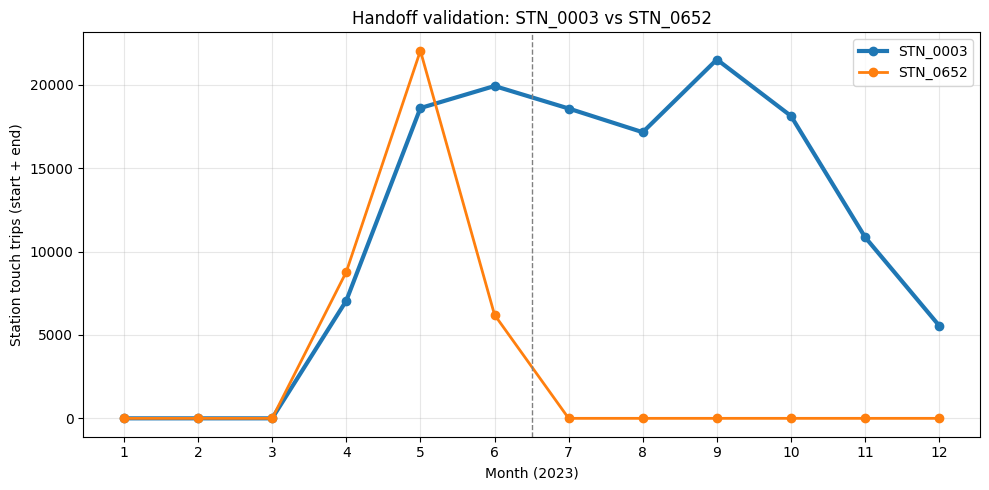

In [29]:
# -------------------------
# Plot STN_0003 vs best candidate (2023)
# -------------------------

compare_ids = [TARGET_STATION, best_handoff_station]

plt.figure(figsize=(10, 5))

for sid in compare_ids:
    s = full_2023_pd[full_2023_pd["station_id"] == sid]

    plt.plot(
        s["month"],
        s["touch_trips"],
        marker="o",
        linewidth=3 if sid == TARGET_STATION else 2,
        label=sid
    )

# Mark handoff boundary
plt.axvline(6.5, color="gray", linestyle="--", linewidth=1)

plt.xticks(range(1, 13))
plt.xlabel("Month (2023)")
plt.ylabel("Station touch trips (start + end)")
plt.title(f"Handoff validation: {TARGET_STATION} vs {best_handoff_station}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### The handoff validation plot shows a clear temporal substitution pattern between STN_0652 and STN_0003. STN_0652 exhibits high activity during months when STN_0003 is initially inactive, and then drops abruptly to zero immediately after mid-year. At the same time, STN_0003 becomes consistently active and maintains high usage levels. This sharp and inverse transition strongly indicates a station ID remapping or data recording change, rather than a genuine shift in user demand.

In [39]:
# print out the lat lon of stn_0003
stn_0003_meta = station_meta_pd[station_meta_pd["station_id"] == TARGET_STATION]
print(f"STN_0003 metadata:")
print(stn_0003_meta[["station_id", "name", "lat", "lon"]])

STN_0003 metadata:
     station_id      name        lat        lon
1002   STN_0003  STN_0003  45.527154 -73.589439


In [32]:
# Task: find all stations in a 200m radius from the given coordinate
lookup_lat, lookup_lon = 45.527154, -73.589439
radius_m = 150.0

# lookup_lat, lookup_lon = 45.52755664225462, -73.58889662657887
# radius_m = 120.0

# lookup_lat, lookup_lon = 45.524236,-73.581552
# radius_m = 200.0

summary_path = "../../data/silver/station_cleaning/station_canonical_summary"
mapping_path = "../../data/silver/station_cleaning/station_direct_match_mapping"

summary_df = spark.read.parquet(summary_path)

stations_base = (
    summary_df
    .select(
        F.col("canonical_station_id").alias("station_id"),
        F.col("canonical_lat").cast("double").alias("lat"),
        F.col("canonical_lon").cast("double").alias("lon")
    )
    .dropna(subset=["station_id", "lat", "lon"])
    .dropDuplicates(["station_id"])
)

# Attach a representative normalized name when available.
mapping_df = spark.read.parquet(mapping_path)
if "normalized_name" in mapping_df.columns:
    names_df = (
        mapping_df
        .groupBy("canonical_station_id")
        .agg(F.first("normalized_name", ignorenulls=True).alias("normalized_name"))
        .withColumnRenamed("canonical_station_id", "station_id")
    )
    stations_base = stations_base.join(names_df, on="station_id", how="left")
else:
    stations_base = stations_base.withColumn("normalized_name", F.lit(None).cast("string"))

# Haversine distance in meters.
R = 6371000.0
lat1 = F.radians(F.lit(lookup_lat))
lon1 = F.radians(F.lit(lookup_lon))
lat2 = F.radians(F.col("lat"))
lon2 = F.radians(F.col("lon"))
dlat = lat2 - lat1
dlon = lon2 - lon1

a = F.pow(F.sin(dlat / 2.0), 2) + F.cos(lat1) * F.cos(lat2) * F.pow(F.sin(dlon / 2.0), 2)
# Guard against tiny floating errors that can push a above 1.
distance_m = F.lit(2.0 * R) * F.asin(F.sqrt(F.least(F.lit(1.0), a)))

stations_radius = (
    stations_base
    .withColumn("distance_m", distance_m)
    .filter(F.col("distance_m") <= F.lit(radius_m))
    .orderBy("distance_m", "station_id")
)

stations_radius_pd = stations_radius.toPandas()
print(f"Stations within {radius_m:.0f}m of ({lookup_lat}, {lookup_lon}): {len(stations_radius_pd)}")
display(stations_radius_pd)

# stations_radius_pd = stations_radius_pd.drop([2,3,6]) # STN_0002

print(stations_radius_pd.to_markdown())

Stations within 150m of (45.527154, -73.589439): 2


,station_id,lat,lon,normalized_name,distance_m
0,STN_0003,45.527154,-73.589439,laurier / st-denis,0.000000
1,STN_0089,45.528100,-73.588439,berri / laurier,130.894316


|    | station_id   |     lat |      lon | normalized_name    |   distance_m |
|---:|:-------------|--------:|---------:|:-------------------|-------------:|
|  0 | STN_0003     | 45.5272 | -73.5894 | laurier / st-denis |        0     |
|  1 | STN_0089     | 45.5281 | -73.5884 | berri / laurier    |      130.894 |


Selected 5 stations: ['STN_0003', 'STN_0089']



Totals across all available data (start+end touches):
  station_id  total_touch_trips_all_data
0   STN_0003                      466292
1   STN_0089                      175763

Total across selected stations (all data): 642055


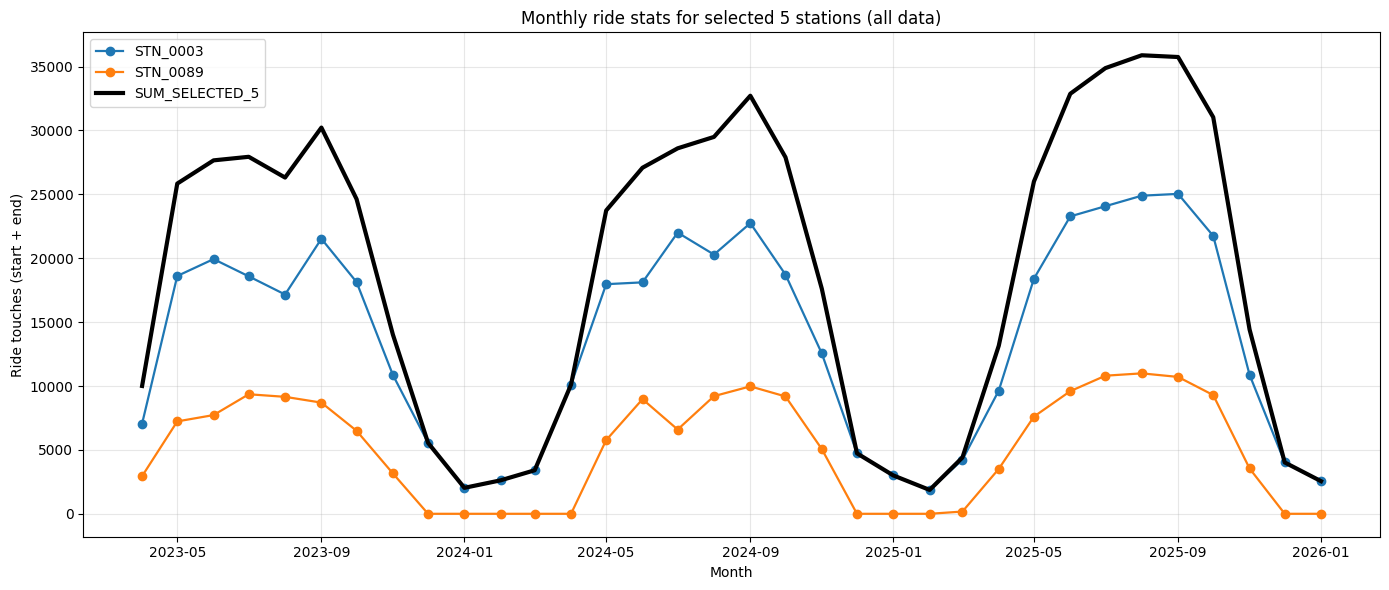

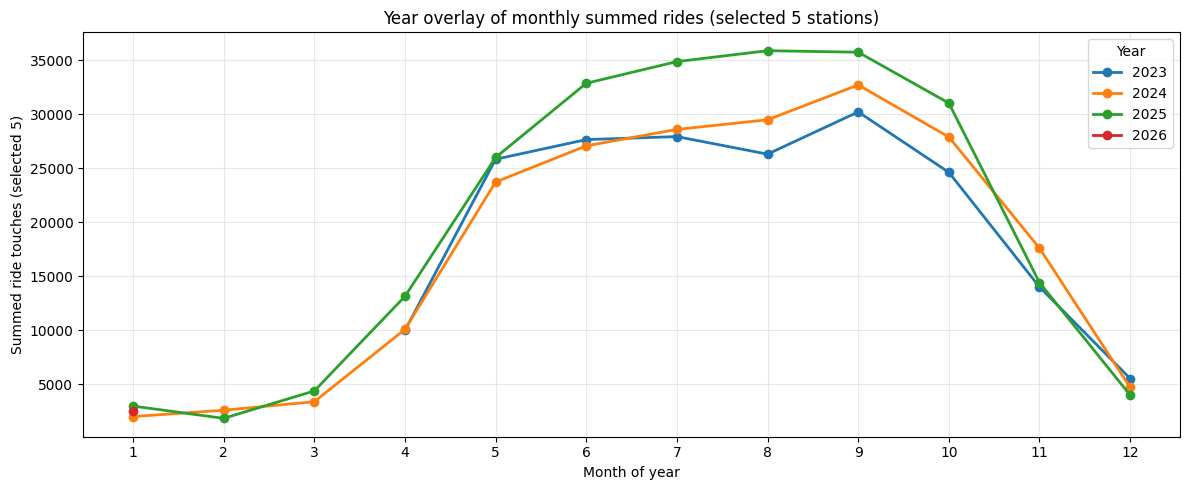

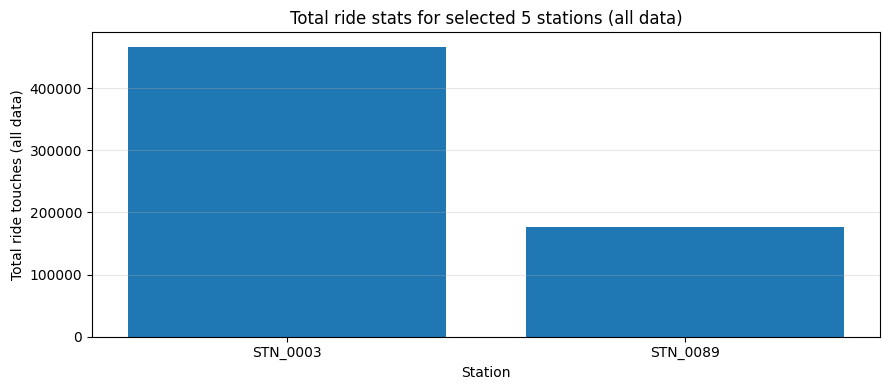

In [40]:
# Task: plot monthly ride stats for 5 stations across all available data (chronological)

# Re-run radius lookup frame with current radius_m setting
if "stations_radius_pd" not in globals() or stations_radius_pd.empty:
    stations_radius_pd = stations_radius.toPandas()

# If you already defined your own 5 stations, keep them.
# Example override: selected_station_ids = ["STN_xxxx", ...]
if "selected_station_ids" in globals() and isinstance(selected_station_ids, list) and len(selected_station_ids) == 5:
    station_ids_5 = selected_station_ids
else:
    station_ids_5 = stations_radius_pd.sort_values("distance_m").head(10)["station_id"].tolist()

print("Selected 5 stations:", station_ids_5)

start_all = (
    rides_df
    .filter(F.col("start_canonical_station_id").isin(station_ids_5))
    .select(
        F.col("start_canonical_station_id").alias("station_id"),
        F.date_trunc("month", F.col("start_time_ms")).alias("event_month")
    )
)

end_all = (
    rides_df
    .filter(F.col("end_canonical_station_id").isin(station_ids_5))
    .select(
        F.col("end_canonical_station_id").alias("station_id"),
        F.date_trunc("month", F.col("end_time_ms")).alias("event_month")
    )
)

monthly_all_pd = (
    start_all
    .unionByName(end_all)
    .groupBy("station_id", "event_month")
    .agg(F.count("*").alias("touch_trips"))
    .orderBy("event_month", "station_id")
    .toPandas()
)

if monthly_all_pd.empty:
    raise RuntimeError("No rides found for selected stations in the available dataset.")

monthly_all_pd["event_month"] = pd.to_datetime(monthly_all_pd["event_month"])

# Ensure every month exists per station for clean chronological lines
min_month = monthly_all_pd["event_month"].min()
max_month = monthly_all_pd["event_month"].max()
all_months = pd.date_range(min_month, max_month, freq="MS")
grid = pd.MultiIndex.from_product([station_ids_5, all_months], names=["station_id", "event_month"]).to_frame(index=False)

monthly_all_pd = (
    grid
    .merge(monthly_all_pd, on=["station_id", "event_month"], how="left")
    .fillna({"touch_trips": 0})
)
monthly_all_pd["touch_trips"] = monthly_all_pd["touch_trips"].astype(int)

# Sum across selected stations for each month
monthly_sum_pd = (
    monthly_all_pd
    .groupby("event_month", as_index=False)["touch_trips"]
    .sum()
    .rename(columns={"touch_trips": "sum_touch_trips"})
)

station_total_pd = (
    monthly_all_pd
    .groupby("station_id", as_index=False)["touch_trips"]
    .sum()
    .rename(columns={"touch_trips": "total_touch_trips_all_data"})
    .sort_values("total_touch_trips_all_data", ascending=False)
)

print("\nTotals across all available data (start+end touches):")
print(station_total_pd)
print("\nTotal across selected stations (all data):", int(monthly_sum_pd["sum_touch_trips"].sum()))

# Plot monthly chronological trends per station + sum line
plt.figure(figsize=(14, 6))
for sid in station_ids_5:
    s = monthly_all_pd[monthly_all_pd["station_id"] == sid].sort_values("event_month")
    plt.plot(s["event_month"], s["touch_trips"], marker="o", linewidth=1.6, label=sid)

plt.plot(
    monthly_sum_pd["event_month"],
    monthly_sum_pd["sum_touch_trips"],
    color="black",
    linewidth=3,
    label="SUM_SELECTED_5"
)

plt.xlabel("Month")
plt.ylabel("Ride touches (start + end)")
plt.title("Monthly ride stats for selected 5 stations (all data)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Overlay by year for the summed series
overlay_pd = monthly_sum_pd.copy()
overlay_pd["year"] = overlay_pd["event_month"].dt.year
overlay_pd["month_num"] = overlay_pd["event_month"].dt.month

plt.figure(figsize=(12, 5))
for y in sorted(overlay_pd["year"].unique()):
    sy = overlay_pd[overlay_pd["year"] == y].sort_values("month_num")
    plt.plot(sy["month_num"], sy["sum_touch_trips"], marker="o", linewidth=2, label=str(y))

plt.xticks(range(1, 13))
plt.xlabel("Month of year")
plt.ylabel("Summed ride touches (selected 5)")
plt.title("Year overlay of monthly summed rides (selected 5 stations)")
plt.grid(alpha=0.3)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

# Plot total bars across all data
plt.figure(figsize=(9, 4))
plt.bar(station_total_pd["station_id"], station_total_pd["total_touch_trips_all_data"])
plt.xlabel("Station")
plt.ylabel("Total ride touches (all data)")
plt.title("Total ride stats for selected 5 stations (all data)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()